In [31]:
import os

os.getcwd()

'c:\\Users\\bhumi\\OneDrive\\Documents\\Luxury_Lifestyle_Category_Analytics\\notebook'

In [32]:
import os

os.listdir("..")

['data', 'notebook']

In [33]:
os.listdir("../data")


['raw']

In [34]:
os.listdir("../data/raw")

['articles.csv', 'customers.csv', 'transactions_train.csv']

In [35]:
import pandas as pd

customers = pd.read_csv("../data/raw/customers.csv")

customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [36]:
customers.columns

Index(['customer_id', 'FN', 'Active', 'club_member_status',
       'fashion_news_frequency', 'age', 'postal_code'],
      dtype='str')

In [37]:
customers.shape

(1371980, 7)

In [38]:
customers.dtypes

customer_id                   str
FN                        float64
Active                    float64
club_member_status            str
fashion_news_frequency        str
age                       float64
postal_code                   str
dtype: object

In [39]:
customers.isnull().sum()

customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

In [40]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [41]:
customers["age"].describe()

count    1.356119e+06
mean     3.638696e+01
std      1.431363e+01
min      1.600000e+01
25%      2.400000e+01
50%      3.200000e+01
75%      4.900000e+01
max      9.900000e+01
Name: age, dtype: float64

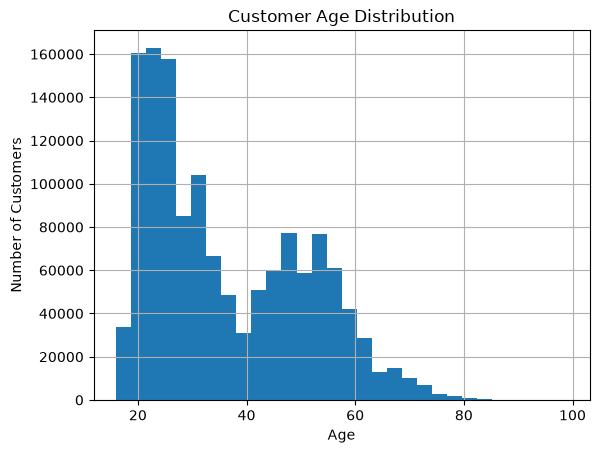

In [42]:
import matplotlib.pyplot as plt

customers["age"].hist(bins=30)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")

plt.show()

In [43]:
customers["age"].value_counts().head(10)

age
21.0    67530
24.0    56124
20.0    55196
25.0    54989
23.0    54867
26.0    53658
22.0    51869
27.0    49134
28.0    44294
29.0    40697
Name: count, dtype: int64

In [44]:
customers["club_member_status"].value_counts(dropna=False)

club_member_status
ACTIVE        1272491
PRE-CREATE      92960
NaN              6062
LEFT CLUB         467
Name: count, dtype: int64

In [45]:
customers["fashion_news_frequency"].value_counts(dropna=False)

fashion_news_frequency
NONE         877711
Regularly    477416
NaN           16011
Monthly         842
Name: count, dtype: int64

In [46]:
customers["FN"].value_counts(dropna=False)

FN
NaN    895050
1.0    476930
Name: count, dtype: int64

In [47]:
customers["Active"].value_counts(dropna=False)


Active
NaN    907576
1.0    464404
Name: count, dtype: int64

In [48]:
customers["customer_id"].str.len().value_counts()

customer_id
64    1371980
Name: count, dtype: int64

In [49]:
articles = pd.read_csv("../data/raw/articles.csv")

articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [50]:
articles.shape

(105542, 25)

In [51]:
articles.columns

Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='str')

In [52]:
articles["article_id"].duplicated().sum()

np.int64(0)

In [53]:
articles.isnull().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [54]:
articles["product_group_name"].value_counts()

product_group_name
Garment Upper body       42741
Garment Lower body       19812
Garment Full body        13292
Accessories              11158
Underwear                 5490
Shoes                     5283
Swimwear                  3127
Socks & Tights            2442
Nightwear                 1899
Unknown                    121
Underwear/nightwear         54
Cosmetic                    49
Bags                        25
Items                       17
Furniture                   13
Garment and Shoe care        9
Stationery                   5
Interior textile             3
Fun                          2
Name: count, dtype: int64

In [55]:
articles["index_name"].value_counts()

index_name
Ladieswear                        26001
Divided                           15149
Menswear                          12553
Children Sizes 92-140             12007
Children Sizes 134-170             9214
Baby Sizes 50-98                   8875
Ladies Accessories                 6961
Lingeries/Tights                   6775
Children Accessories, Swimwear     4615
Sport                              3392
Name: count, dtype: int64

In [56]:
transactions_sample = pd.read_csv(
    "../data/raw/transactions_train.csv",
    nrows=5
)

transactions_sample

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [57]:
id="x3k9qp"
transactions_sample.dtypes

t_dat                   str
customer_id             str
article_id            int64
price               float64
sales_channel_id      int64
dtype: object

In [58]:
transactions_sample["t_dat"] = pd.to_datetime(transactions_sample["t_dat"])

transactions_sample.dtypes

t_dat               datetime64[us]
customer_id                    str
article_id                   int64
price                      float64
sales_channel_id             int64
dtype: object

In [59]:
transactions_sample["t_dat"].min(), transactions_sample["t_dat"].max()

(Timestamp('2018-09-20 00:00:00'), Timestamp('2018-09-20 00:00:00'))

In [60]:
transactions_sample["sales_channel_id"].value_counts()

sales_channel_id
2    5
Name: count, dtype: int64

In [61]:
transactions_sample["article_id"].dtype, transactions_sample["article_id"].nunique()                                                                                                                       

(dtype('int64'), 5)

In [62]:
transactions_sample["price"].describe()

count    5.000000
mean     0.026085
std      0.015141
min      0.015237
25%      0.016932
50%      0.016932
75%      0.030492
max      0.050831
Name: price, dtype: float64

In [63]:
transactions_sample.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

In [64]:
transactions_sample["customer_id"].str.len().value_counts()

customer_id
64    5
Name: count, dtype: int64

In [65]:
transactions_sample["t_dat"].dt.strftime("%Y-%m-%d")

0    2018-09-20
1    2018-09-20
2    2018-09-20
3    2018-09-20
4    2018-09-20
Name: t_dat, dtype: str

In [66]:
transactions_sample["price"].min(), transactions_sample["price"].max()

(np.float64(0.0152372881355932), np.float64(0.0508305084745762))

In [67]:
transactions_sample["sales_channel_id"].unique()

array([2])

In [68]:
transactions_sample["article_id"].astype(str).str.len().value_counts()

article_id
9    5
Name: count, dtype: int64

In [69]:
transactions_sample.duplicated(
    subset=["t_dat", "customer_id", "article_id"]
).sum()

np.int64(0)

In [70]:
total_transactions = 0

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat"],
    chunksize=500_000
):
    total_transactions += len(chunk)

total_transactions


31788324

In [71]:
min_date = None
max_date = None

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat"],
    parse_dates=["t_dat"],
    chunksize=500_000
):
    chunk_min = chunk["t_dat"].min()
    chunk_max = chunk["t_dat"].max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

min_date, max_date

(Timestamp('2018-09-20 00:00:00'), Timestamp('2020-09-22 00:00:00'))

In [72]:
unique_customers = set()

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["customer_id"],
    chunksize=500_000
):
    unique_customers.update(chunk["customer_id"].unique())

len(unique_customers)

1362281

In [73]:
unique_articles = set()

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["article_id"],
    chunksize=500_000
):
    unique_articles.update(chunk["article_id"].unique())

len(unique_articles)

104547

In [74]:
channel_counts = {}

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["sales_channel_id"],
    chunksize=500_000
):
    counts = chunk["sales_channel_id"].value_counts()

    for channel, count in counts.items():
        channel_counts[channel] = channel_counts.get(channel, 0) + count

channel_counts

{2: 22379862, 1: 9408462}

In [75]:
total = sum(channel_counts.values())

{
    channel: round(count / total * 100, 2)
    for channel, count in channel_counts.items()
}

{2: 70.4, 1: 29.6}

In [76]:
price_stats = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["price"],
    chunksize=500_000
):
    price_stats.append(chunk["price"])

all_prices = pd.concat(price_stats, ignore_index=True)

all_prices.describe()

count    3.178832e+07
mean     2.782927e-02
std      1.918113e-02
min      1.694915e-05
25%      1.581356e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.915254e-01
Name: price, dtype: float64

In [77]:
del all_prices

In [78]:
duplicate_count = 0

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    chunksize=500_000
):
    duplicate_count += chunk.duplicated().sum()

duplicate_count

np.int64(2974899)

In [79]:
duplicate_examples = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    chunksize=500_000
):
    dupes = chunk[chunk.duplicated(keep=False)]
    
    if len(dupes) > 0:
        duplicate_examples.append(dupes.head(10))
    
    if len(duplicate_examples) >= 1:
        break

pd.concat(duplicate_examples)

,t_dat,customer_id,article_id,price,sales_channel_id
14,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,501820043,0.016932,2
15,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,501820043,0.016932,2
17,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,671505001,0.033881,2
18,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,671505001,0.033881,2
19,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,631848002,0.033881,2
20,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,631848002,0.033881,2
21,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,631848002,0.033881,2
22,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,631848002,0.033881,2
24,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,676827002,0.042356,2
25,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,676827002,0.042356,2


In [81]:
repeat_count = 0

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat", "customer_id", "article_id"],
    chunksize=500_000
):
    repeat_count += chunk.duplicated(
        subset=["t_dat", "customer_id", "article_id"],
        keep=False
    ).sum()

repeat_count

np.int64(5930761)

In [82]:
monthly_transactions = {}

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat"],
    parse_dates=["t_dat"],
    chunksize=500_000
):
    months = chunk["t_dat"].dt.to_period("M").value_counts()

    for month, count in months.items():
        monthly_transactions[month] = monthly_transactions.get(month, 0) + count

monthly_transactions = pd.Series(monthly_transactions).sort_index()

monthly_transactions

2018-09     594776
2018-10    1397040
2018-11    1270619
2018-12    1148827
2019-01    1263471
2019-02    1152412
2019-03    1286750
2019-04    1476454
2019-05    1560319
2019-06    1906202
2019-07    1807494
2019-08    1253530
2019-09    1227178
2019-10    1146772
2019-11    1198033
2019-12    1118315
2020-01    1076354
2020-02    1001859
2020-03    1047752
2020-04    1340882
2020-05    1361815
2020-06    1764507
2020-07    1351502
2020-08    1237192
2020-09     798269
Freq: M, dtype: int64

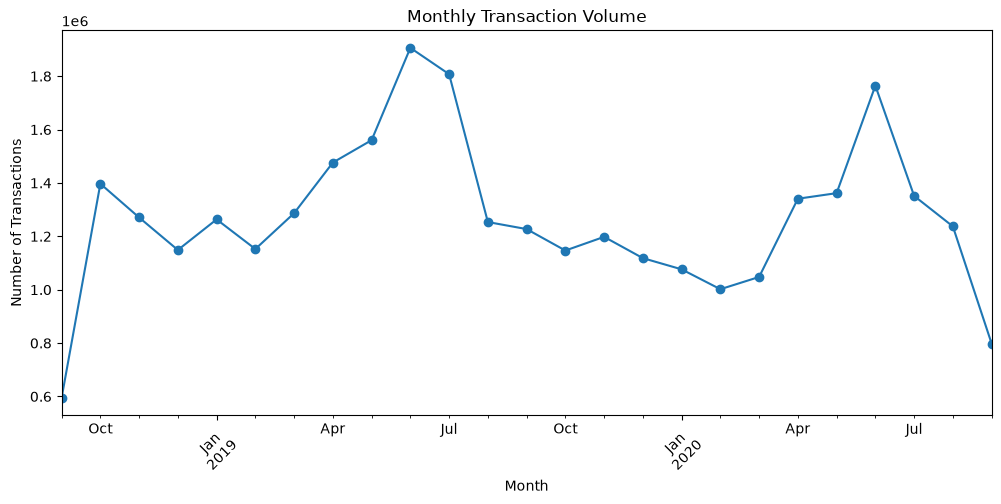

In [83]:
monthly_transactions.plot(
    figsize=(12, 5),
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.title("Monthly Transaction Volume")
plt.xticks(rotation=45)
plt.show()

In [84]:
customer_transaction_counts = {}

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["customer_id"],
    chunksize=500_000
):
    counts = chunk["customer_id"].value_counts()

    for customer, count in counts.items():
        customer_transaction_counts[customer] = (
            customer_transaction_counts.get(customer, 0) + count
        )

customer_transaction_counts = pd.Series(customer_transaction_counts)

customer_transaction_counts.describe()

count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64

In [85]:
customer_transaction_counts.value_counts().sort_index().head(20)

1     131514
2     127441
3      95686
4      82082
5      64635
6      56820
7      47385
8      43047
9      37627
10     34262
11     30337
12     27985
13     25114
14     23585
15     21685
16     20158
17     19070
18     17969
19     16618
20     16084
Name: count, dtype: int64

In [86]:
customer_transaction_counts.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25      3.0
0.50      9.0
0.75     27.0
0.90     60.0
0.95     91.0
0.99    187.0
dtype: float64

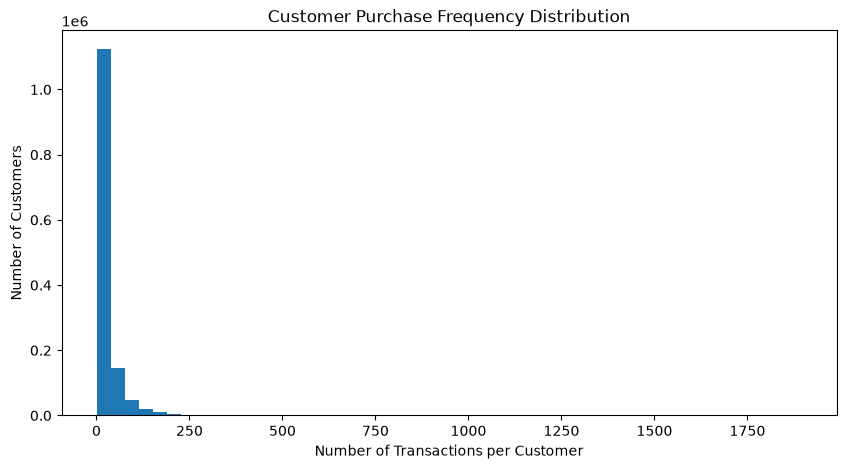

In [87]:
customer_transaction_counts.plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.xlabel("Number of Transactions per Customer")
plt.ylabel("Number of Customers")
plt.title("Customer Purchase Frequency Distribution")
plt.show()

In [88]:
article_transaction_counts = {}

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["article_id"],
    chunksize=500_000
):
    counts = chunk["article_id"].value_counts()

    for article, count in counts.items():
        article_transaction_counts[article] = (
            article_transaction_counts.get(article, 0) + count
        )

article_transaction_counts = pd.Series(article_transaction_counts)

article_transaction_counts.sort_values(ascending=False).head(10)

706016001    50287
706016002    35043
372860001    31718
610776002    30199
759871002    26329
464297007    25025
372860002    24458
610776001    22451
399223001    22236
706016003    21241
dtype: int64

In [89]:
top_articles = article_transaction_counts.sort_values(ascending=False).head(10)

top_articles_df = (
    top_articles
    .rename("transaction_count")
    .reset_index()
    .rename(columns={"index": "article_id"})
)

top_articles_df = top_articles_df.merge(
    articles[[
        "article_id",
        "prod_name",
        "product_type_name",
        "product_group_name",
        "index_name"
    ]],
    on="article_id",
    how="left"
)

top_articles_df

,article_id,transaction_count,prod_name,product_type_name,product_group_name,index_name
0,706016001,50287,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Divided
1,706016002,35043,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Divided
2,372860001,31718,7p Basic Shaftless,Socks,Socks & Tights,Lingeries/Tights
3,610776002,30199,Tilly (1),T-shirt,Garment Upper body,Ladieswear
4,759871002,26329,Tilda tank,Vest top,Garment Upper body,Divided
5,464297007,25025,Greta Thong Mynta Low 3p,Underwear bottom,Underwear,Lingeries/Tights
6,372860002,24458,7p Basic Shaftless,Socks,Socks & Tights,Lingeries/Tights
7,610776001,22451,Tilly (1),T-shirt,Garment Upper body,Ladieswear
8,399223001,22236,Curvy Jeggings HW Ankle,Trousers,Garment Lower body,Divided
9,706016003,21241,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Divided


In [90]:
article_transaction_counts.quantile([0.50, 0.75, 0.90, 0.95, 0.99])

0.50      65.00
0.75     286.00
0.90     793.00
0.95    1318.00
0.99    3185.08
dtype: float64

In [91]:
group_transaction_counts = {}

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["article_id"],
    chunksize=500_000
):
    counts = chunk["article_id"].value_counts()

    for article, count in counts.items():
        group_transaction_counts[article] = (
            group_transaction_counts.get(article, 0) + count
        )

group_transaction_counts = pd.Series(group_transaction_counts)

group_sales = (
    group_transaction_counts.rename("transaction_count")
    .reset_index()
    .rename(columns={"index": "article_id"})
    .merge(
        articles[["article_id", "product_group_name"]],
        on="article_id",
        how="left"
    )
    .groupby("product_group_name")["transaction_count"]
    .sum()
    .sort_values(ascending=False)
)

group_sales

product_group_name
Garment Upper body       12552755
Garment Lower body        7046054
Garment Full body         3552470
Swimwear                  2579222
Underwear                 2565858
Accessories               1599593
Shoes                      745521
Socks & Tights             685712
Nightwear                  348180
Unknown                     97040
Bags                         7313
Items                        5427
Cosmetic                     1500
Underwear/nightwear           559
Furniture                     533
Garment and Shoe care         279
Stationery                    229
Interior textile               74
Fun                             5
Name: transaction_count, dtype: int64

In [92]:
group_sales_share = (group_sales / group_sales.sum() * 100).round(2)

group_sales_share

product_group_name
Garment Upper body       39.49
Garment Lower body       22.17
Garment Full body        11.18
Swimwear                  8.11
Underwear                 8.07
Accessories               5.03
Shoes                     2.35
Socks & Tights            2.16
Nightwear                 1.10
Unknown                   0.31
Bags                      0.02
Items                     0.02
Cosmetic                  0.00
Underwear/nightwear       0.00
Furniture                 0.00
Garment and Shoe care     0.00
Stationery                0.00
Interior textile          0.00
Fun                       0.00
Name: transaction_count, dtype: float64

In [93]:
group_sales_df = pd.DataFrame({
    "transaction_count": group_sales,
    "transaction_share_pct": group_sales_share
})

group_sales_df

,transaction_count,transaction_share_pct
product_group_name,,
Garment Upper body,12552755,39.49
Garment Lower body,7046054,22.17
Garment Full body,3552470,11.18
Swimwear,2579222,8.11
Underwear,2565858,8.07
Accessories,1599593,5.03
Shoes,745521,2.35
Socks & Tights,685712,2.16
Nightwear,348180,1.10


In [94]:
del article_transaction_counts
del group_transaction_counts

In [95]:
import os

os.makedirs("../data/interim", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

os.listdir("../data")

['interim', 'processed', 'raw']

In [96]:
transaction_sample = pd.read_csv(
    "../data/raw/transactions_train.csv",
    nrows=1_000_000
)

transaction_sample.to_csv(
    "../data/interim/transactions_sample_1m.csv",
    index=False
)

transaction_sample.shape

(1000000, 5)

In [97]:
transaction_sample.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [98]:
transaction_sample["t_dat"] = pd.to_datetime(transaction_sample["t_dat"])

transaction_sample.dtypes

t_dat               datetime64[us]
customer_id                    str
article_id                   int64
price                      float64
sales_channel_id             int64
dtype: object

In [99]:
transaction_sample["month"] = transaction_sample["t_dat"].dt.to_period("M")

transaction_sample[["t_dat", "month"]].head()

,t_dat,month
0,2018-09-20,2018-09
1,2018-09-20,2018-09
2,2018-09-20,2018-09
3,2018-09-20,2018-09
4,2018-09-20,2018-09


In [100]:
transaction_sample["sales_value"] = transaction_sample["price"]

transaction_sample[["price", "sales_value"]].head()


,price,sales_value
0,0.050831,0.050831
1,0.030492,0.030492
2,0.015237,0.015237
3,0.016932,0.016932
4,0.016932,0.016932


In [101]:
monthly_summary = (
    transaction_sample
    .groupby("month")
    .agg(
        transaction_count=("article_id", "count"),
        total_sales_value=("sales_value", "sum")
    )
    .reset_index()
)

monthly_summary.head()

,month,transaction_count,total_sales_value
0,2018-09,594776,17755.639593
1,2018-10,405224,12423.183068


In [102]:
monthly_summary["avg_transaction_value"] = (
    monthly_summary["total_sales_value"] /
    monthly_summary["transaction_count"]
)

monthly_summary

,month,transaction_count,total_sales_value,avg_transaction_value
0,2018-09,594776,17755.639593,0.029853
1,2018-10,405224,12423.183068,0.030658


In [103]:
channel_summary = (
    transaction_sample
    .groupby("sales_channel_id")
    .agg(
        transaction_count=("article_id", "count"),
        total_sales_value=("sales_value", "sum")
    )
    .reset_index()
)

channel_summary

,sales_channel_id,transaction_count,total_sales_value
0,1,337057,8920.118627
1,2,662943,21258.704034


In [104]:
transaction_sample = transaction_sample.merge(
    articles[
        [
            "article_id",
            "prod_name",
            "product_type_name",
            "product_group_name",
            "index_name",
            "department_name"
        ]
    ],
    on="article_id",
    how="left"
)

transaction_sample.head()

,t_dat,customer_id,article_id,price,sales_channel_id,month,sales_value,prod_name,product_type_name,product_group_name,index_name,department_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,2018-09,0.050831,Atlanta Push Body Harlow,Underwear body,Underwear,Lingeries/Tights,Expressive Lingerie
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,2018-09,0.030492,Rae Push (Melbourne) 2p,Bra,Underwear,Lingeries/Tights,Casual Lingerie
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,2018-09,0.015237,Inca Jumper,Sweater,Garment Upper body,Divided,Tops Knitwear DS
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,2018-09,0.016932,W YODA KNIT OL OFFER,Sweater,Garment Upper body,Ladieswear,Campaigns
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,2018-09,0.016932,W YODA KNIT OL OFFER,Sweater,Garment Upper body,Ladieswear,Campaigns


In [105]:
product_group_summary = (
    transaction_sample
    .groupby("product_group_name")
    .agg(
        transaction_count=("article_id", "count"),
        total_sales_value=("sales_value", "sum")
    )
    .sort_values("total_sales_value", ascending=False)
    .reset_index()
)

product_group_summary

,product_group_name,transaction_count,total_sales_value
0,Garment Upper body,499296,15594.060678
1,Garment Lower body,231284,7906.026814
2,Garment Full body,61497,2220.188186
3,Underwear,63964,1377.047424
4,Shoes,24995,1104.445153
5,Accessories,53055,925.198390
6,Socks & Tights,31011,386.267271
7,Swimwear,22720,364.981508
8,Nightwear,11139,277.953576
9,Unknown,607,17.530203


In [106]:
product_group_summary["sales_share_pct"] = (
    product_group_summary["total_sales_value"]
    / product_group_summary["total_sales_value"].sum()
    * 100
)

product_group_summary

,product_group_name,transaction_count,total_sales_value,sales_share_pct
0,Garment Upper body,499296,15594.060678,51.672197
1,Garment Lower body,231284,7906.026814,26.197267
2,Garment Full body,61497,2220.188186,7.356775
3,Underwear,63964,1377.047424,4.562959
4,Shoes,24995,1104.445153,3.659669
5,Accessories,53055,925.198390,3.065721
6,Socks & Tights,31011,386.267271,1.279928
7,Swimwear,22720,364.981508,1.209396
8,Nightwear,11139,277.953576,0.921022
9,Unknown,607,17.530203,0.058088


In [107]:
assortment_summary = (
    articles
    .groupby("product_group_name")
    .agg(
        article_count=("article_id", "count")
    )
    .reset_index()
)

assortment_summary["assortment_share_pct"] = (
    assortment_summary["article_count"]
    / assortment_summary["article_count"].sum()
    * 100
)

assortment_summary.sort_values(
    "assortment_share_pct",
    ascending=False
)

,product_group_name,article_count,assortment_share_pct
7,Garment Upper body,42741,40.496674
6,Garment Lower body,19812,18.771674
5,Garment Full body,13292,12.594038
0,Accessories,11158,10.572095
16,Underwear,5490,5.201721
12,Shoes,5283,5.005590
15,Swimwear,3127,2.962802
13,Socks & Tights,2442,2.313771
11,Nightwear,1899,1.799284
18,Unknown,121,0.114646


In [108]:
portfolio_summary = assortment_summary.merge(
    product_group_summary[
        [
            "product_group_name",
            "transaction_count",
            "total_sales_value",
            "sales_share_pct"
        ]
    ],
    on="product_group_name",
    how="left"
)

portfolio_summary = portfolio_summary.sort_values(
    "sales_share_pct",
    ascending=False
)

portfolio_summary

,product_group_name,article_count,assortment_share_pct,transaction_count,total_sales_value,sales_share_pct
7,Garment Upper body,42741,40.496674,499296.0,15594.060678,51.672197
6,Garment Lower body,19812,18.771674,231284.0,7906.026814,26.197267
5,Garment Full body,13292,12.594038,61497.0,2220.188186,7.356775
16,Underwear,5490,5.201721,63964.0,1377.047424,4.562959
12,Shoes,5283,5.005590,24995.0,1104.445153,3.659669
0,Accessories,11158,10.572095,53055.0,925.198390,3.065721
13,Socks & Tights,2442,2.313771,31011.0,386.267271,1.279928
15,Swimwear,3127,2.962802,22720.0,364.981508,1.209396
11,Nightwear,1899,1.799284,11139.0,277.953576,0.921022
18,Unknown,121,0.114646,607.0,17.530203,0.058088


In [109]:
portfolio_summary["sales_vs_assortment_gap"] = (
    portfolio_summary["sales_share_pct"]
    - portfolio_summary["assortment_share_pct"]
)

portfolio_summary[
    [
        "product_group_name",
        "assortment_share_pct",
        "sales_share_pct",
        "sales_vs_assortment_gap"
    ]
]

,product_group_name,assortment_share_pct,sales_share_pct,sales_vs_assortment_gap
7,Garment Upper body,40.496674,51.672197,11.175523
6,Garment Lower body,18.771674,26.197267,7.425593
5,Garment Full body,12.594038,7.356775,-5.237263
16,Underwear,5.201721,4.562959,-0.638761
12,Shoes,5.005590,3.659669,-1.345921
0,Accessories,10.572095,3.065721,-7.506374
13,Socks & Tights,2.313771,1.279928,-1.033843
15,Swimwear,2.962802,1.209396,-1.753405
11,Nightwear,1.799284,0.921022,-0.878262
18,Unknown,0.114646,0.058088,-0.056559


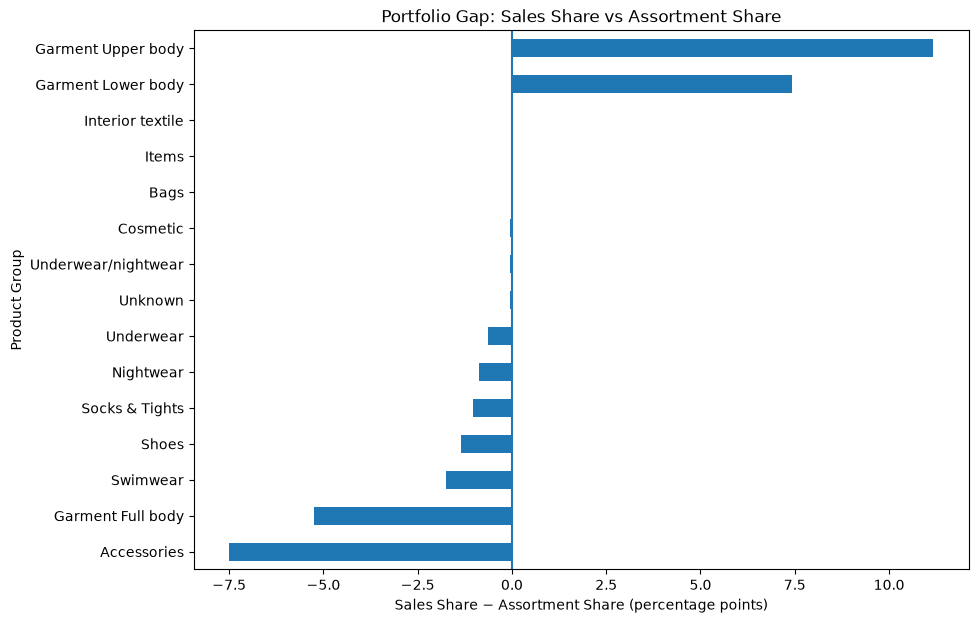

In [110]:
portfolio_plot = portfolio_summary.dropna(
    subset=["sales_vs_assortment_gap"]
).copy()

portfolio_plot = portfolio_plot.sort_values(
    "sales_vs_assortment_gap"
)

portfolio_plot.plot(
    x="product_group_name",
    y="sales_vs_assortment_gap",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.xlabel("Sales Share − Assortment Share (percentage points)")
plt.ylabel("Product Group")
plt.title("Portfolio Gap: Sales Share vs Assortment Share")
plt.axvline(0)
plt.show()

In [111]:
monthly_data = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat", "price"],
    chunksize=500_000
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])
    chunk["month"] = chunk["t_dat"].dt.to_period("M")

    monthly_chunk = (
        chunk
        .groupby("month")
        .agg(
            transaction_count=("price", "count"),
            total_sales_value=("price", "sum")
        )
    )

    monthly_data.append(monthly_chunk)

monthly_summary_full = (
    pd.concat(monthly_data)
    .groupby(level=0)
    .sum()
    .reset_index()
)

monthly_summary_full["avg_transaction_value"] = (
    monthly_summary_full["total_sales_value"]
    / monthly_summary_full["transaction_count"]
)

monthly_summary_full.to_csv(
    "../data/processed/monthly_sales_summary.csv",
    index=False
)

monthly_summary_full

,month,transaction_count,total_sales_value,avg_transaction_value
0,2018-09,594776,17755.639593,0.029853
1,2018-10,1397040,41584.816610,0.029766
2,2018-11,1270619,39000.988390,0.030694
3,2018-12,1148827,32532.514712,0.028318
4,2019-01,1263471,33449.981475,0.026475
5,2019-02,1152412,31428.221814,0.027272
6,2019-03,1286750,37549.020169,0.029181
7,2019-04,1476454,42824.987305,0.029005
8,2019-05,1560319,43357.502322,0.027788
9,2019-06,1906202,48648.417864,0.025521


In [112]:
monthly_summary_full["transaction_growth_pct"] = (
    monthly_summary_full["transaction_count"]
    .pct_change()
    * 100
)

monthly_summary_full[
    [
        "month",
        "transaction_count",
        "transaction_growth_pct"
    ]
]

,month,transaction_count,transaction_growth_pct
0,2018-09,594776,NaN
1,2018-10,1397040,134.885066
2,2018-11,1270619,-9.049204
3,2018-12,1148827,-9.585249
4,2019-01,1263471,9.979222
5,2019-02,1152412,-8.789992
6,2019-03,1286750,11.657116
7,2019-04,1476454,14.742879
8,2019-05,1560319,5.680163
9,2019-06,1906202,22.167454


In [113]:
monthly_summary_full["year"] = monthly_summary_full["month"].dt.year
monthly_summary_full["month_num"] = monthly_summary_full["month"].dt.month

seasonal_summary = (
    monthly_summary_full
    .groupby("month_num")
    .agg(
        avg_transactions=("transaction_count", "mean"),
        avg_sales_value=("total_sales_value", "mean")
    )
    .reset_index()
)

seasonal_summary

,month_num,avg_transactions,avg_sales_value
0,1,1.169912e+06,31121.782483
1,2,1.077136e+06,30110.549314
2,3,1.167251e+06,33911.612415
3,4,1.408668e+06,40316.736483
4,5,1.461067e+06,40251.598347
5,6,1.835354e+06,45851.888466
6,7,1.579498e+06,36375.068271
7,8,1.245361e+06,31838.172992
8,9,8.734077e+05,28287.705249
9,10,1.271906e+06,39286.262602


In [114]:
seasonal_summary["month_name"] = pd.to_datetime(
    seasonal_summary["month_num"],
    format="%m"
).dt.month_name()

seasonal_summary[
    ["month_num", "month_name", "avg_transactions", "avg_sales_value"]
]

,month_num,month_name,avg_transactions,avg_sales_value
0,1,January,1.169912e+06,31121.782483
1,2,February,1.077136e+06,30110.549314
2,3,March,1.167251e+06,33911.612415
3,4,April,1.408668e+06,40316.736483
4,5,May,1.461067e+06,40251.598347
5,6,June,1.835354e+06,45851.888466
6,7,July,1.579498e+06,36375.068271
7,8,August,1.245361e+06,31838.172992
8,9,September,8.734077e+05,28287.705249
9,10,October,1.271906e+06,39286.262602


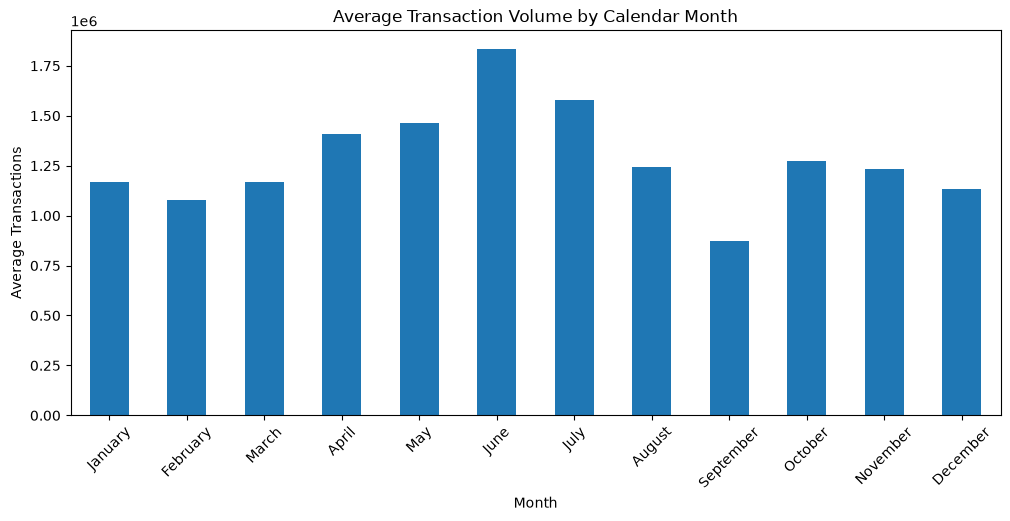

In [115]:
seasonal_summary.plot(
    x="month_name",
    y="avg_transactions",
    kind="bar",
    figsize=(12, 5),
    legend=False
)

plt.xlabel("Month")
plt.ylabel("Average Transactions")
plt.title("Average Transaction Volume by Calendar Month")
plt.xticks(rotation=45)
plt.show()

In [116]:
customer_rfm_parts = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat", "customer_id", "price"],
    chunksize=500_000
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])

    chunk_summary = (
        chunk
        .groupby("customer_id")
        .agg(
            last_purchase_date=("t_dat", "max"),
            transaction_count=("t_dat", "count"),
            total_sales_value=("price", "sum")
        )
    )

    customer_rfm_parts.append(chunk_summary)

customer_summary = (
    pd.concat(customer_rfm_parts)
    .groupby(level=0)
    .agg(
        last_purchase_date=("last_purchase_date", "max"),
        transaction_count=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

customer_summary.head()

,customer_id,last_purchase_date,transaction_count,total_sales_value
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,2020-09-05,21,0.648983
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2020-07-08,86,2.601932
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2020-09-15,18,0.704780
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2019-06-09,2,0.060983
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,2020-08-12,13,0.469695


In [117]:
reference_date = pd.Timestamp("2020-09-23")

customer_summary["recency_days"] = (
    reference_date - customer_summary["last_purchase_date"]
).dt.days

customer_summary[
    [
        "customer_id",
        "last_purchase_date",
        "recency_days",
        "transaction_count",
        "total_sales_value"
    ]
].head()

,customer_id,last_purchase_date,recency_days,transaction_count,total_sales_value
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,2020-09-05,18,21,0.648983
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2020-07-08,77,86,2.601932
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2020-09-15,8,18,0.704780
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2019-06-09,472,2,0.060983
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,2020-08-12,42,13,0.469695


In [118]:
customer_summary[
    [
        "recency_days",
        "transaction_count",
        "total_sales_value"
    ]
].describe()

,recency_days,transaction_count,total_sales_value
count,1.362281e+06,1.362281e+06,1.362281e+06
mean,2.361484e+02,2.333463e+01,6.493858e-01
std,2.211188e+02,3.924225e+01,1.197582e+00
min,1.000000e+00,1.000000e+00,7.627119e-04
25%,4.900000e+01,3.000000e+00,8.806780e-02
50%,1.520000e+02,9.000000e+00,2.455932e-01
75%,3.990000e+02,2.700000e+01,7.011864e-01
max,7.340000e+02,1.895000e+03,5.767641e+01


In [119]:
customer_summary["R_score"] = pd.qcut(
    customer_summary["recency_days"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

customer_summary["F_score"] = pd.qcut(
    customer_summary["transaction_count"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

customer_summary["M_score"] = pd.qcut(
    customer_summary["total_sales_value"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

customer_summary[
    [
        "customer_id",
        "recency_days",
        "transaction_count",
        "total_sales_value",
        "R_score",
        "F_score",
        "M_score"
    ]
].head()

,customer_id,recency_days,transaction_count,total_sales_value,R_score,F_score,M_score
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,18,21,0.648983,5,4,4
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,77,86,2.601932,4,5,5
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,8,18,0.704780,5,4,4
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,472,2,0.060983,1,1,1
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,42,13,0.469695,4,3,4


In [120]:
customer_summary["RFM_score"] = (
    customer_summary["R_score"].astype(int).astype(str)
    + customer_summary["F_score"].astype(int).astype(str)
    + customer_summary["M_score"].astype(int).astype(str)
)

customer_summary[
    [
        "customer_id",
        "R_score",
        "F_score",
        "M_score",
        "RFM_score"
    ]
].head()

,customer_id,R_score,F_score,M_score,RFM_score
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,5,4,4,544
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,4,5,5,455
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,5,4,4,544
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,1,1,1,111
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,4,3,4,434


In [121]:

def assign_segment(row):
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 4 and m >= 3 and r >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 3:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    else:
        return "Low Engagement"

customer_summary["segment"] = customer_summary.apply(
    assign_segment,
    axis=1
)

customer_summary[
    ["customer_id", "RFM_score", "segment"]
].head()

,customer_id,RFM_score,segment
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,544,Champions
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,455,Champions
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,544,Champions
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,111,Low Engagement
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,434,Potential Loyalists


In [122]:
segment_summary = (
    customer_summary
    .groupby("segment")
    .agg(
        customer_count=("customer_id", "count"),
        total_sales_value=("total_sales_value", "sum"),
        avg_transactions=("transaction_count", "mean"),
        avg_sales_value=("total_sales_value", "mean")
    )
    .reset_index()
)

segment_summary["customer_share_pct"] = (
    segment_summary["customer_count"]
    / segment_summary["customer_count"].sum()
    * 100
)

segment_summary["sales_share_pct"] = (
    segment_summary["total_sales_value"]
    / segment_summary["total_sales_value"].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    "total_sales_value",
    ascending=False
)

segment_summary

,segment,customer_count,total_sales_value,avg_transactions,avg_sales_value,customer_share_pct,sales_share_pct
1,Champions,344583,594446.288136,61.582437,1.725118,25.294561,67.195952
3,Loyal Customers,119387,110500.675407,33.858259,0.925567,8.763757,12.490949
0,At Risk,200221,92016.971237,17.129197,0.459577,14.697482,10.401559
2,Low Engagement,514613,55130.712271,3.690039,0.107130,37.775833,6.231952
4,Potential Loyalists,183477,32551.327000,6.525396,0.177414,13.468367,3.679588


In [123]:
segment_summary = segment_summary.reset_index(drop=True)

segment_summary["total_sales_value"] = (
    segment_summary["total_sales_value"].round(2)
)

segment_summary["avg_transactions"] = (
    segment_summary["avg_transactions"].round(2)
)

segment_summary["avg_sales_value"] = (
    segment_summary["avg_sales_value"].round(2)
)

segment_summary["customer_share_pct"] = (
    segment_summary["customer_share_pct"].round(2)
)

segment_summary["sales_share_pct"] = (
    segment_summary["sales_share_pct"].round(2)
)

segment_summary


,segment,customer_count,total_sales_value,avg_transactions,avg_sales_value,customer_share_pct,sales_share_pct
0,Champions,344583,594446.29,61.58,1.73,25.29,67.20
1,Loyal Customers,119387,110500.68,33.86,0.93,8.76,12.49
2,At Risk,200221,92016.97,17.13,0.46,14.70,10.40
3,Low Engagement,514613,55130.71,3.69,0.11,37.78,6.23
4,Potential Loyalists,183477,32551.33,6.53,0.18,13.47,3.68


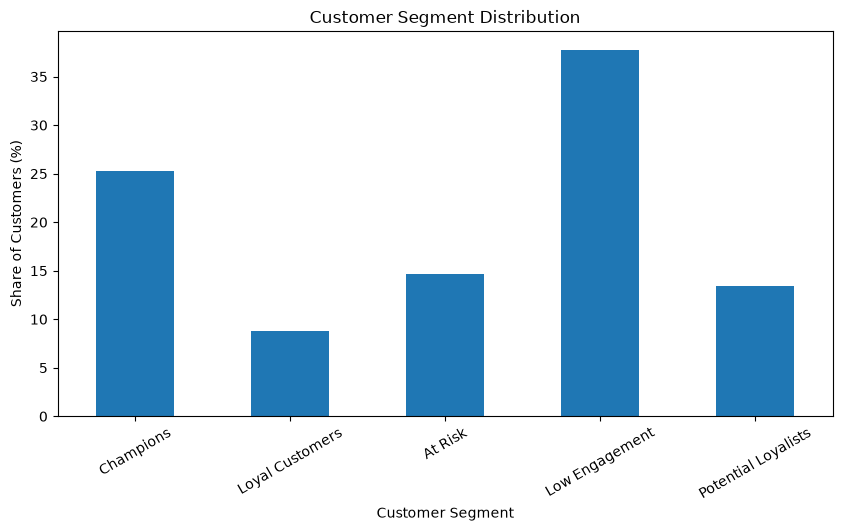

In [124]:
segment_summary.plot(
    x="segment",
    y="customer_share_pct",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.xlabel("Customer Segment")
plt.ylabel("Share of Customers (%)")
plt.title("Customer Segment Distribution")
plt.xticks(rotation=30)
plt.show()


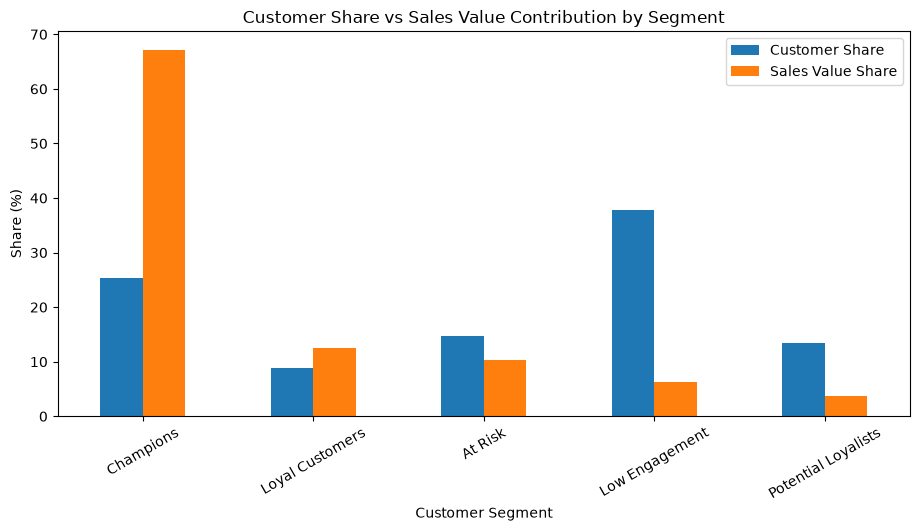

In [125]:
segment_comparison = segment_summary[
    ["segment", "customer_share_pct", "sales_share_pct"]
].copy()

segment_comparison.plot(
    x="segment",
    y=["customer_share_pct", "sales_share_pct"],
    kind="bar",
    figsize=(11, 5)
)

plt.xlabel("Customer Segment")
plt.ylabel("Share (%)")
plt.title("Customer Share vs Sales Value Contribution by Segment")
plt.xticks(rotation=30)
plt.legend(
    ["Customer Share", "Sales Value Share"]
)
plt.show()

In [126]:
customer_summary.to_csv(
    "../data/processed/customer_rfm_segments.csv",
    index=False
)

segment_summary.to_csv(
    "../data/processed/rfm_segment_summary.csv",
    index=False
)

print("RFM files saved successfully.")

RFM files saved successfully.


In [127]:
price_values = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["price"],
    chunksize=500_000
):
    price_values.append(chunk["price"])

all_prices = pd.concat(price_values, ignore_index=True)

print("Transaction count:", len(all_prices))
print("\nPrice statistics:")
print(all_prices.describe())

print("\nPrice percentiles:")
print(
    all_prices.quantile(
        [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Transaction count: 31788324

Price statistics:
count    3.178832e+07
mean     2.782927e-02
std      1.918113e-02
min      1.694915e-05
25%      1.581356e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.915254e-01
Name: price, dtype: float64

Price percentiles:
0.01    0.003576
0.05    0.007610
0.10    0.010102
0.25    0.015814
0.50    0.025407
0.75    0.033881
0.90    0.050831
0.95    0.059305
0.99    0.100220
Name: price, dtype: float64


In [128]:
all_prices_df = pd.DataFrame({
    "price": all_prices
})

all_prices_df["price_band"] = pd.qcut(
    all_prices_df["price"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

price_band_summary = (
    all_prices_df
    .groupby("price_band", observed=True)
    .agg(
        transaction_count=("price", "count"),
        total_sales_value=("price", "sum"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

price_band_summary["transaction_share_pct"] = (
    price_band_summary["transaction_count"]
    / price_band_summary["transaction_count"].sum()
    * 100
)

price_band_summary["sales_value_share_pct"] = (
    price_band_summary["total_sales_value"]
    / price_band_summary["total_sales_value"].sum()
    * 100
)

price_band_summary

,price_band,transaction_count,total_sales_value,avg_price,transaction_share_pct,sales_value_share_pct
0,Very Low,6726200,65573.635966,0.009749,21.159341,7.412416
1,Low,6107733,103491.113712,0.016944,19.213762,11.698591
2,Medium,6584964,160449.940288,0.024366,20.715040,18.137192
3,High,6109789,200433.480797,0.032805,19.220230,22.656914
4,Very High,6259638,354697.803288,0.056664,19.691626,40.094887


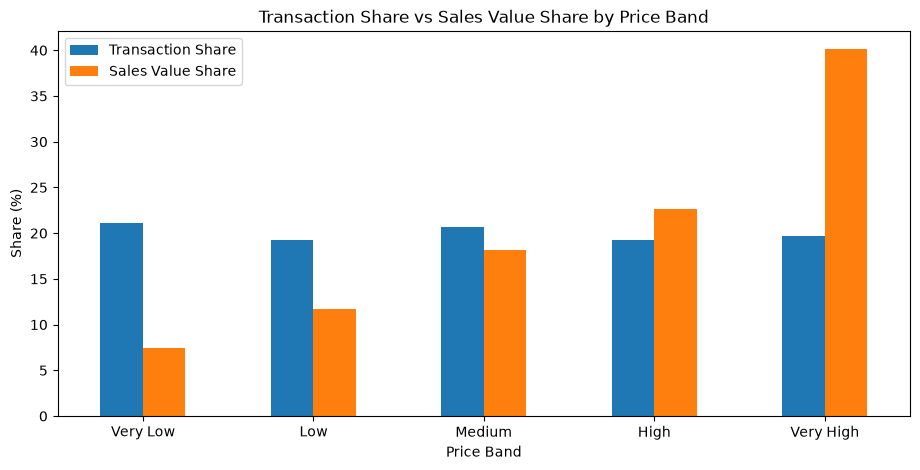

In [129]:
price_band_summary.plot(
    x="price_band",
    y=["transaction_share_pct", "sales_value_share_pct"],
    kind="bar",
    figsize=(11, 5)
)

plt.xlabel("Price Band")
plt.ylabel("Share (%)")
plt.title("Transaction Share vs Sales Value Share by Price Band")
plt.xticks(rotation=0)
plt.legend(
    ["Transaction Share", "Sales Value Share"]
)
plt.show()

In [130]:
article_lookup = articles[
    ["article_id", "product_group_name"]
].copy()

price_category_parts = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["article_id", "price"],
    chunksize=500_000
):
    chunk = chunk.merge(
        article_lookup,
        on="article_id",
        how="left"
    )

    summary = (
        chunk
        .groupby("product_group_name")
        .agg(
            transaction_count=("price", "count"),
            total_sales_value=("price", "sum"),
            avg_price=("price", "mean"),
            median_price=("price", "median")
        )
    )

    price_category_parts.append(summary)

price_category_summary = (
    pd.concat(price_category_parts)
    .groupby(level=0)
    .agg(
        transaction_count=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

price_category_summary["avg_price"] = (
    pd.concat(price_category_parts)
    .groupby(level=0)["total_sales_value"].sum()
    / price_category_summary["transaction_count"].values
)

price_category_summary = price_category_summary.sort_values(
    "total_sales_value",
    ascending=False
)

price_category_summary

,product_group_name,transaction_count,total_sales_value,avg_price
7,Garment Upper body,12552755,338981.789203,NaN
6,Garment Lower body,7046054,231774.620034,NaN
5,Garment Full body,3552470,128478.941678,NaN
15,Swimwear,2579222,57628.166508,NaN
16,Underwear,2565858,54395.857458,NaN
12,Shoes,745521,28888.356373,NaN
0,Accessories,1599593,24893.822424,NaN
11,Nightwear,348180,8852.815390,NaN
13,Socks & Tights,685712,7811.136525,NaN
18,Unknown,97040,2598.734051,NaN


In [131]:
price_category_summary["avg_price"] = (
    price_category_summary["total_sales_value"]
    / price_category_summary["transaction_count"]
)

price_category_summary["sales_value_share_pct"] = (
    price_category_summary["total_sales_value"]
    / price_category_summary["total_sales_value"].sum()
    * 100
)

price_category_summary["transaction_share_pct"] = (
    price_category_summary["transaction_count"]
    / price_category_summary["transaction_count"].sum()
    * 100
)

price_category_summary = price_category_summary.round({
    "total_sales_value": 2,
    "avg_price": 5,
    "sales_value_share_pct": 2,
    "transaction_share_pct": 2
})

price_category_summary

,product_group_name,transaction_count,total_sales_value,avg_price,sales_value_share_pct,transaction_share_pct
7,Garment Upper body,12552755,338981.79,0.02700,38.32,39.49
6,Garment Lower body,7046054,231774.62,0.03289,26.20,22.17
5,Garment Full body,3552470,128478.94,0.03617,14.52,11.18
15,Swimwear,2579222,57628.17,0.02234,6.51,8.11
16,Underwear,2565858,54395.86,0.02120,6.15,8.07
12,Shoes,745521,28888.36,0.03875,3.27,2.35
0,Accessories,1599593,24893.82,0.01556,2.81,5.03
11,Nightwear,348180,8852.82,0.02543,1.00,1.10
13,Socks & Tights,685712,7811.14,0.01139,0.88,2.16
18,Unknown,97040,2598.73,0.02678,0.29,0.31


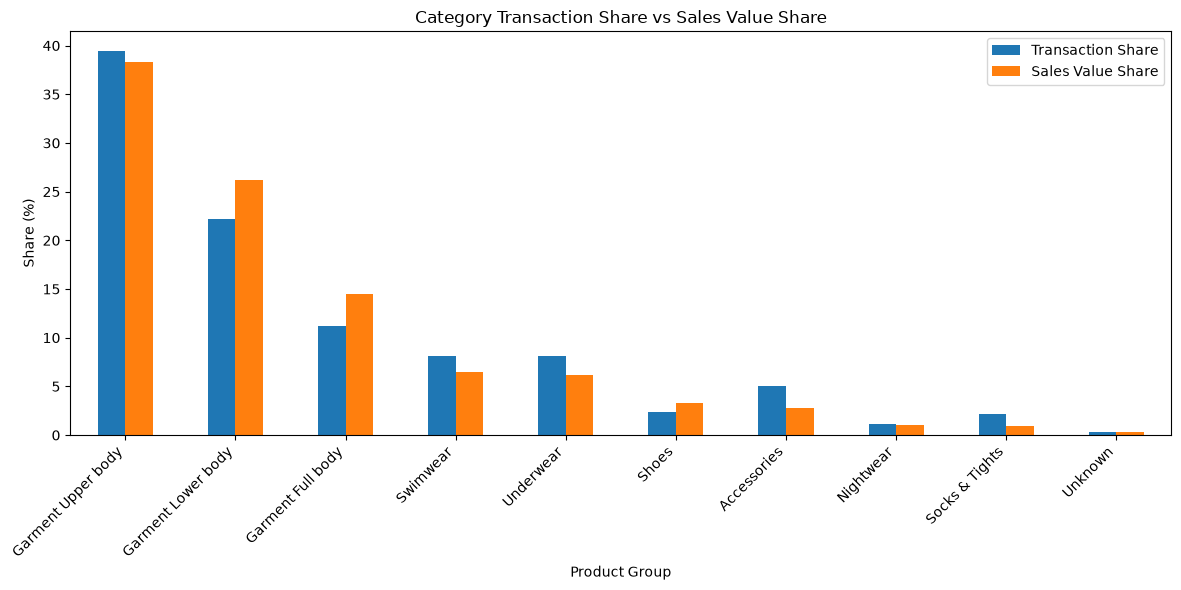

In [132]:
category_plot = price_category_summary[
    price_category_summary["transaction_count"] >= 10000
].copy()

category_plot.plot(
    x="product_group_name",
    y=["transaction_share_pct", "sales_value_share_pct"],
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Product Group")
plt.ylabel("Share (%)")
plt.title("Category Transaction Share vs Sales Value Share")
plt.xticks(rotation=45, ha="right")
plt.legend(
    ["Transaction Share", "Sales Value Share"]
)
plt.tight_layout()
plt.show()

In [133]:
price_category_summary["value_mix_gap_pp"] = (
    price_category_summary["sales_value_share_pct"]
    - price_category_summary["transaction_share_pct"]
)

category_gap = price_category_summary[
    price_category_summary["transaction_count"] >= 10000
].copy()

category_gap = category_gap.sort_values(
    "value_mix_gap_pp",
    ascending=True
)

category_gap[
    [
        "product_group_name",
        "transaction_share_pct",
        "sales_value_share_pct",
        "value_mix_gap_pp"
    ]
]

,product_group_name,transaction_share_pct,sales_value_share_pct,value_mix_gap_pp
0,Accessories,5.03,2.81,-2.22
16,Underwear,8.07,6.15,-1.92
15,Swimwear,8.11,6.51,-1.60
13,Socks & Tights,2.16,0.88,-1.28
7,Garment Upper body,39.49,38.32,-1.17
11,Nightwear,1.10,1.00,-0.10
18,Unknown,0.31,0.29,-0.02
12,Shoes,2.35,3.27,0.92
5,Garment Full body,11.18,14.52,3.34
6,Garment Lower body,22.17,26.20,4.03


In [134]:
category_price_ranking = price_category_summary[
    price_category_summary["transaction_count"] >= 10000
].copy()

category_price_ranking = category_price_ranking.sort_values(
    "avg_price",
    ascending=False
)

category_price_ranking[
    [
        "product_group_name",
        "transaction_count",
        "avg_price",
        "transaction_share_pct",
        "sales_value_share_pct"
    ]
]

,product_group_name,transaction_count,avg_price,transaction_share_pct,sales_value_share_pct
12,Shoes,745521,0.03875,2.35,3.27
5,Garment Full body,3552470,0.03617,11.18,14.52
6,Garment Lower body,7046054,0.03289,22.17,26.20
7,Garment Upper body,12552755,0.02700,39.49,38.32
18,Unknown,97040,0.02678,0.31,0.29
11,Nightwear,348180,0.02543,1.10,1.00
15,Swimwear,2579222,0.02234,8.11,6.51
16,Underwear,2565858,0.02120,8.07,6.15
0,Accessories,1599593,0.01556,5.03,2.81
13,Socks & Tights,685712,0.01139,2.16,0.88


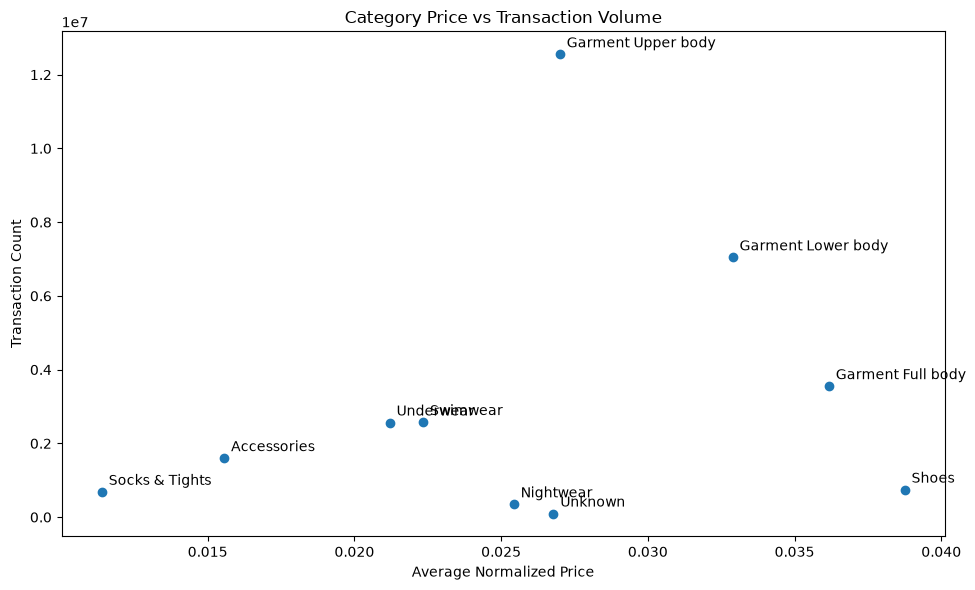

In [135]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_price_ranking["avg_price"],
    category_price_ranking["transaction_count"]
)

for _, row in category_price_ranking.iterrows():
    plt.annotate(
        row["product_group_name"],
        (row["avg_price"], row["transaction_count"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Normalized Price")
plt.ylabel("Transaction Count")
plt.title("Category Price vs Transaction Volume")

plt.tight_layout()
plt.show()

In [136]:
category_price_band_parts = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["article_id", "price"],
    chunksize=500_000
):
    chunk = chunk.merge(
        article_lookup,
        on="article_id",
        how="left"
    )

    chunk["price_band"] = pd.cut(
        chunk["price"],
        bins=[
            -float("inf"),
            all_prices.quantile(0.20),
            all_prices.quantile(0.40),
            all_prices.quantile(0.60),
            all_prices.quantile(0.80),
            float("inf")
        ],
        labels=[
            "Very Low",
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

    summary = (
        chunk
        .groupby(
            ["product_group_name", "price_band"],
            observed=True
        )
        .agg(
            transaction_count=("price", "count"),
            total_sales_value=("price", "sum")
        )
        .reset_index()
    )

    category_price_band_parts.append(summary)

category_price_band_summary = (
    pd.concat(category_price_band_parts)
    .groupby(
        ["product_group_name", "price_band"],
        observed=True
    )
    .agg(
        transaction_count=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

category_price_band_summary

,product_group_name,price_band,transaction_count,total_sales_value
0,Accessories,Very Low,969404,8954.550237
1,Accessories,Low,263086,4426.828492
2,Accessories,Medium,205102,4930.440339
3,Accessories,High,100190,3239.884102
4,Accessories,Very High,61811,3342.119254
...,...,...,...,...
76,Unknown,Very Low,6438,57.902068
77,Unknown,Low,16968,291.944831
78,Unknown,Medium,40684,990.858390
79,Unknown,High,23548,768.767729


In [137]:
category_price_band_summary["category_transaction_share_pct"] = (
    category_price_band_summary["transaction_count"]
    / category_price_band_summary
        .groupby("product_group_name")["transaction_count"]
        .transform("sum")
    * 100
)

category_price_band_summary["category_sales_value_share_pct"] = (
    category_price_band_summary["total_sales_value"]
    / category_price_band_summary
        .groupby("product_group_name")["total_sales_value"]
        .transform("sum")
    * 100
)

category_price_band_summary = category_price_band_summary.round({
    "total_sales_value": 2,
    "category_transaction_share_pct": 2,
    "category_sales_value_share_pct": 2
})

category_price_band_summary

,product_group_name,price_band,transaction_count,total_sales_value,category_transaction_share_pct,category_sales_value_share_pct
0,Accessories,Very Low,969404,8954.55,60.60,35.97
1,Accessories,Low,263086,4426.83,16.45,17.78
2,Accessories,Medium,205102,4930.44,12.82,19.81
3,Accessories,High,100190,3239.88,6.26,13.01
4,Accessories,Very High,61811,3342.12,3.86,13.43
...,...,...,...,...,...,...
76,Unknown,Very Low,6438,57.90,6.63,2.23
77,Unknown,Low,16968,291.94,17.49,11.23
78,Unknown,Medium,40684,990.86,41.92,38.13
79,Unknown,High,23548,768.77,24.27,29.58


In [138]:
major_category_price_mix = category_price_band_summary[
    category_price_band_summary["transaction_count"] >= 10000
].copy()

dominant_price_band = (
    major_category_price_mix
    .loc[
        major_category_price_mix
        .groupby("product_group_name")["category_transaction_share_pct"]
        .idxmax()
    ]
    [
        [
            "product_group_name",
            "price_band",
            "category_transaction_share_pct",
            "category_sales_value_share_pct"
        ]
    ]
    .sort_values(
        "category_transaction_share_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

dominant_price_band

,product_group_name,price_band,category_transaction_share_pct,category_sales_value_share_pct
0,Socks & Tights,Very Low,77.99,65.15
1,Accessories,Very Low,60.60,35.97
2,Shoes,Very High,42.99,66.70
3,Unknown,Medium,41.92,38.13
4,Garment Full body,Very High,36.59,56.58
5,Swimwear,Medium,31.67,34.34
6,Nightwear,Medium,30.75,29.63
7,Garment Lower body,High,29.33,29.55
8,Underwear,Medium,28.48,32.30
9,Garment Upper body,Very Low,25.03,8.92


In [139]:
price_band_summary.to_csv(
    "../data/processed/price_band_summary.csv",
    index=False
)

price_category_summary.to_csv(
    "../data/processed/category_price_summary.csv",
    index=False
)

category_price_band_summary.to_csv(
    "../data/processed/category_price_band_summary.csv",
    index=False
)

dominant_price_band.to_csv(
    "../data/processed/dominant_category_price_band.csv",
    index=False
)

print("Pricing analysis files saved successfully.")

Pricing analysis files saved successfully.


In [140]:
product_demand_parts = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["article_id", "price"],
    chunksize=500_000
):
    summary = (
        chunk
        .groupby("article_id")
        .agg(
            transaction_count=("price", "count"),
            total_sales_value=("price", "sum")
        )
    )

    product_demand_parts.append(summary)

product_demand = (
    pd.concat(product_demand_parts)
    .groupby(level=0)
    .agg(
        transaction_count=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

product_demand = product_demand.merge(
    articles[
        [
            "article_id",
            "prod_name",
            "product_type_name",
            "product_group_name",
            "index_name",
            "department_name"
        ]
    ],
    on="article_id",
    how="left"
)

product_demand = product_demand.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True)

product_demand.head(20)

,article_id,transaction_count,total_sales_value,prod_name,product_type_name,product_group_name,index_name,department_name
0,706016001,50287,1631.732102,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Divided,Trousers
1,706016002,35043,1136.321085,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Divided,Trousers
2,372860001,31718,411.003780,7p Basic Shaftless,Socks,Socks & Tights,Lingeries/Tights,Shopbasket Socks
3,610776002,30199,244.101610,Tilly (1),T-shirt,Garment Upper body,Ladieswear,Jersey Basic
4,759871002,26329,147.575661,Tilda tank,Vest top,Garment Upper body,Divided,EQ Divided Basics
5,464297007,25025,405.193000,Greta Thong Mynta Low 3p,Underwear bottom,Underwear,Lingeries/Tights,Casual Lingerie
6,372860002,24458,297.284746,7p Basic Shaftless,Socks,Socks & Tights,Lingeries/Tights,Shopbasket Socks
7,610776001,22451,181.381678,Tilly (1),T-shirt,Garment Upper body,Ladieswear,Jersey Basic
8,399223001,22236,686.484780,Curvy Jeggings HW Ankle,Trousers,Garment Lower body,Divided,Denim Trousers
9,706016003,21241,692.195915,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Divided,Trousers


In [141]:
product_demand["transaction_share_pct"] = (
    product_demand["transaction_count"]
    / product_demand["transaction_count"].sum()
    * 100
)

product_demand["sales_value_share_pct"] = (
    product_demand["total_sales_value"]
    / product_demand["total_sales_value"].sum()
    * 100
)

top_products = product_demand.head(20).copy()

top_products[
    [
        "article_id",
        "prod_name",
        "product_type_name",
        "product_group_name",
        "transaction_count",
        "transaction_share_pct",
        "total_sales_value",
        "sales_value_share_pct"
    ]
]

,article_id,prod_name,product_type_name,product_group_name,transaction_count,transaction_share_pct,total_sales_value,sales_value_share_pct
0,706016001,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,50287,0.158193,1631.732102,0.184450
1,706016002,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,35043,0.110239,1136.321085,0.128449
2,372860001,7p Basic Shaftless,Socks,Socks & Tights,31718,0.099779,411.003780,0.046460
3,610776002,Tilly (1),T-shirt,Garment Upper body,30199,0.095000,244.101610,0.027593
4,759871002,Tilda tank,Vest top,Garment Upper body,26329,0.082826,147.575661,0.016682
5,464297007,Greta Thong Mynta Low 3p,Underwear bottom,Underwear,25025,0.078724,405.193000,0.045803
6,372860002,7p Basic Shaftless,Socks,Socks & Tights,24458,0.076940,297.284746,0.033605
7,610776001,Tilly (1),T-shirt,Garment Upper body,22451,0.070627,181.381678,0.020503
8,399223001,Curvy Jeggings HW Ankle,Trousers,Garment Lower body,22236,0.069950,686.484780,0.077600
9,706016003,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,21241,0.066820,692.195915,0.078246


In [142]:
product_name_demand = (
    product_demand
    .groupby("prod_name", dropna=False)
    .agg(
        article_variant_count=("article_id", "nunique"),
        transaction_count=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

product_name_demand["transaction_share_pct"] = (
    product_name_demand["transaction_count"]
    / product_name_demand["transaction_count"].sum()
    * 100
)

product_name_demand["sales_value_share_pct"] = (
    product_name_demand["total_sales_value"]
    / product_name_demand["total_sales_value"].sum()
    * 100
)

product_name_demand = product_name_demand.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True)

product_name_demand.head(20)

,prod_name,article_variant_count,transaction_count,total_sales_value,transaction_share_pct,sales_value_share_pct
0,Jade HW Skinny Denim TRS,19,168052,5398.928237,0.528660,0.610293
1,Luna skinny RW,34,143216,4178.059525,0.450530,0.472286
2,Timeless Midrise Brief,30,122143,1906.257949,0.384239,0.215483
3,Tilly (1),29,105670,852.298458,0.332418,0.096343
4,Cat Tee.,28,81304,656.533898,0.255767,0.074214
5,Simple as That Triangle Top,17,74827,1794.061712,0.235391,0.202800
6,Shake it in Balconette,31,74574,1637.161068,0.234596,0.185064
7,Tilda tank,20,68891,394.500186,0.216718,0.044594
8,Despacito,48,67607,1534.471051,0.212679,0.173456
9,Simple as that Cheeky Tanga,14,64603,1016.010898,0.203229,0.114849


In [143]:
portfolio_products = product_name_demand[
    product_name_demand["transaction_count"] >= 1000
].copy()

volume_median = portfolio_products["transaction_share_pct"].median()
value_median = portfolio_products["sales_value_share_pct"].median()

def classify_product(row):
    high_volume = row["transaction_share_pct"] >= volume_median
    high_value = row["sales_value_share_pct"] >= value_median

    if high_volume and high_value:
        return "High Volume / High Value"
    elif high_volume and not high_value:
        return "High Volume / Lower Value"
    elif not high_volume and high_value:
        return "Lower Volume / High Value"
    else:
        return "Lower Volume / Lower Value"

portfolio_products["portfolio_segment"] = (
    portfolio_products.apply(classify_product, axis=1)
)

print("Volume median:", round(volume_median, 4))
print("Value median:", round(value_median, 4))

portfolio_products[
    [
        "prod_name",
        "article_variant_count",
        "transaction_count",
        "transaction_share_pct",
        "sales_value_share_pct",
        "portfolio_segment"
    ]
].head(30)

Volume median: 0.0067
Value median: 0.0069


,prod_name,article_variant_count,transaction_count,transaction_share_pct,sales_value_share_pct,portfolio_segment
0,Jade HW Skinny Denim TRS,19,168052,0.528660,0.610293,High Volume / High Value
1,Luna skinny RW,34,143216,0.450530,0.472286,High Volume / High Value
2,Timeless Midrise Brief,30,122143,0.384239,0.215483,High Volume / High Value
3,Tilly (1),29,105670,0.332418,0.096343,High Volume / High Value
4,Cat Tee.,28,81304,0.255767,0.074214,High Volume / High Value
5,Simple as That Triangle Top,17,74827,0.235391,0.202800,High Volume / High Value
6,Shake it in Balconette,31,74574,0.234596,0.185064,High Volume / High Value
7,Tilda tank,20,68891,0.216718,0.044594,High Volume / High Value
8,Despacito,48,67607,0.212679,0.173456,High Volume / High Value
9,Simple as that Cheeky Tanga,14,64603,0.203229,0.114849,High Volume / High Value


In [144]:
portfolio_segment_summary = (
    portfolio_products
    .groupby("portfolio_segment")
    .agg(
        product_family_count=("prod_name", "count"),
        total_transactions=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

portfolio_segment_summary["transaction_share_pct"] = (
    portfolio_segment_summary["total_transactions"]
    / portfolio_segment_summary["total_transactions"].sum()
    * 100
)

portfolio_segment_summary["sales_value_share_pct"] = (
    portfolio_segment_summary["total_sales_value"]
    / portfolio_segment_summary["total_sales_value"].sum()
    * 100
)

portfolio_segment_summary = portfolio_segment_summary.sort_values(
    "sales_value_share_pct",
    ascending=False
).reset_index(drop=True)

portfolio_segment_summary.round({
    "total_sales_value": 2,
    "transaction_share_pct": 2,
    "sales_value_share_pct": 2
})

,portfolio_segment,product_family_count,total_transactions,total_sales_value,transaction_share_pct,sales_value_share_pct
0,High Volume / High Value,2481,18301570,482650.26,72.72,73.20
1,Lower Volume / Lower Value,2481,3479577,84087.37,13.83,12.75
2,Lower Volume / High Value,725,1178357,61865.23,4.68,9.38
3,High Volume / Lower Value,725,2207183,30721.89,8.77,4.66


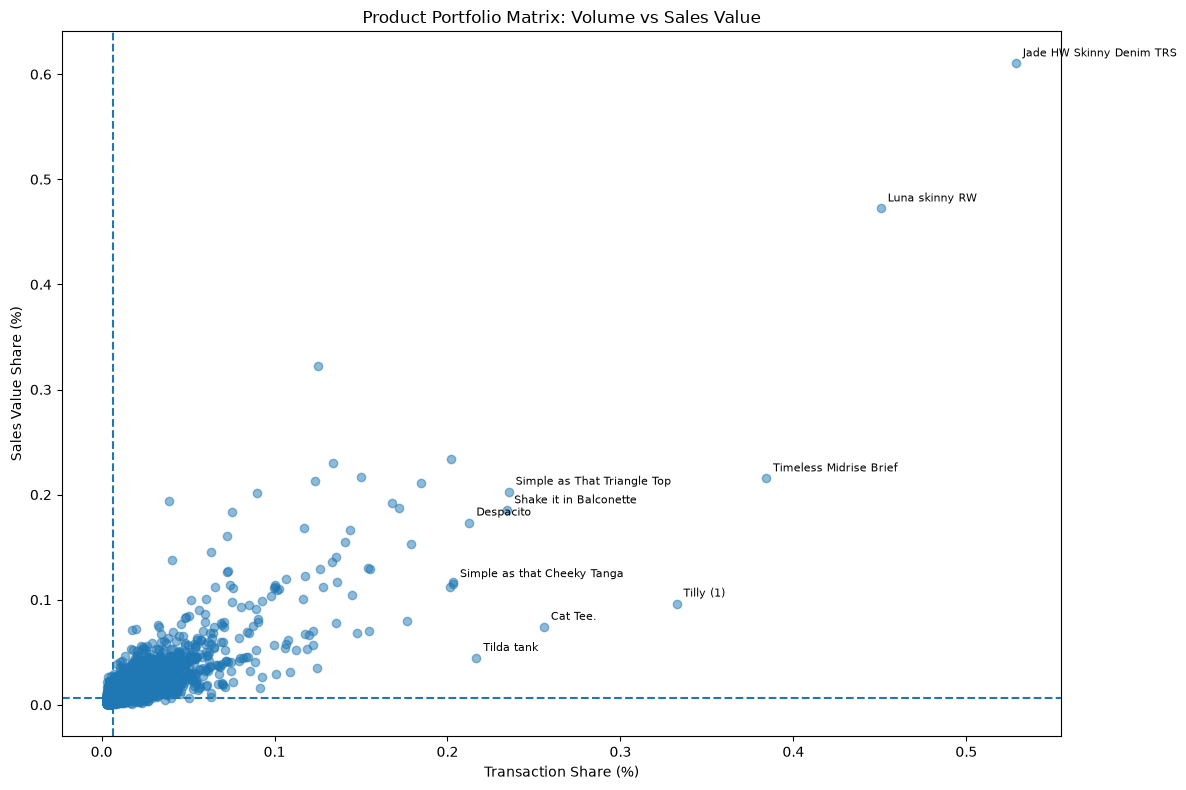

In [145]:
plt.figure(figsize=(12, 8))

plt.scatter(
    portfolio_products["transaction_share_pct"],
    portfolio_products["sales_value_share_pct"],
    alpha=0.5
)

plt.axvline(
    volume_median,
    linestyle="--"
)

plt.axhline(
    value_median,
    linestyle="--"
)

top_families = portfolio_products.nlargest(
    10,
    "transaction_share_pct"
)

for _, row in top_families.iterrows():
    plt.annotate(
        row["prod_name"],
        (
            row["transaction_share_pct"],
            row["sales_value_share_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Transaction Share (%)")
plt.ylabel("Sales Value Share (%)")
plt.title("Product Portfolio Matrix: Volume vs Sales Value")

plt.tight_layout()
plt.show()

In [146]:
variant_demand = product_name_demand[
    product_name_demand["transaction_count"] >= 1000
].copy()

variant_demand["transactions_per_variant"] = (
    variant_demand["transaction_count"]
    / variant_demand["article_variant_count"]
)

variant_demand = variant_demand.sort_values(
    "transactions_per_variant",
    ascending=False
).reset_index(drop=True)

variant_demand[
    [
        "prod_name",
        "article_variant_count",
        "transaction_count",
        "transactions_per_variant",
        "total_sales_value"
    ]
].head(20)

,prod_name,article_variant_count,transaction_count,transactions_per_variant,total_sales_value
0,7p Basic Shaftless,2,56176,28088.000000,708.288525
1,Highwaist 30 den 1p Tights,1,16533,16533.000000,203.321068
2,Shape Up 30 den 1p Tights,1,14191,14191.000000,170.806932
3,Support 40 den 1p Tights,1,13888,13888.000000,169.220966
4,3p Sneaker Socks,3,38847,12949.000000,502.168678
5,Harrison short sleeve top CN,1,12519,12519.000000,204.456814
6,Long Leggings,1,11518,11518.000000,170.158288
7,Box 4p Tights,2,22643,11321.500000,148.202525
8,Curvy Jeggings HW Ankle,3,33926,11308.666667,1060.792932
9,Rebecca or Delphine shirt,2,22294,11147.000000,531.454661


In [147]:
variant_demand["variant_breadth_group"] = pd.cut(
    variant_demand["article_variant_count"],
    bins=[0, 2, 5, 10, 20, float("inf")],
    labels=[
        "1–2 variants",
        "3–5 variants",
        "6–10 variants",
        "11–20 variants",
        "21+ variants"
    ]
)

breadth_summary = (
    variant_demand
    .groupby("variant_breadth_group", observed=True)
    .agg(
        product_family_count=("prod_name", "count"),
        total_transactions=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum"),
        avg_transactions_per_variant=("transactions_per_variant", "mean")
    )
    .reset_index()
)

breadth_summary

,variant_breadth_group,product_family_count,total_transactions,total_sales_value,avg_transactions_per_variant
0,1–2 variants,2162,4582242,129725.968153,1347.151249
1,3–5 variants,2697,8621466,237003.276271,873.513021
2,6–10 variants,1035,5805241,146634.009780,763.227673
3,11–20 variants,410,4208184,104656.801763,727.849186
4,21+ variants,108,1949554,41304.700441,632.588444


In [148]:
product_demand.to_csv(
    "../data/processed/product_demand.csv",
    index=False
)

product_name_demand.to_csv(
    "../data/processed/product_name_demand.csv",
    index=False
)

portfolio_products.to_csv(
    "../data/processed/product_portfolio_matrix.csv",
    index=False
)

portfolio_segment_summary.to_csv(
    "../data/processed/portfolio_segment_summary.csv",
    index=False
)

variant_demand.to_csv(
    "../data/processed/product_variant_demand.csv",
    index=False
)

breadth_summary.to_csv(
    "../data/processed/assortment_breadth_summary.csv",
    index=False
)

print("Product portfolio analysis files saved successfully.")

Product portfolio analysis files saved successfully.


In [149]:
rfm_behavior_summary = (
    customer_summary
    .groupby("segment")
    .agg(
        customer_count=("customer_id", "count"),
        avg_recency_days=("recency_days", "mean"),
        avg_transaction_count=("transaction_count", "mean"),
        avg_sales_value=("total_sales_value", "mean"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

rfm_behavior_summary["customer_share_pct"] = (
    rfm_behavior_summary["customer_count"]
    / rfm_behavior_summary["customer_count"].sum()
    * 100
)

rfm_behavior_summary["sales_value_share_pct"] = (
    rfm_behavior_summary["total_sales_value"]
    / rfm_behavior_summary["total_sales_value"].sum()
    * 100
)

rfm_behavior_summary = rfm_behavior_summary.sort_values(
    "total_sales_value",
    ascending=False
).reset_index(drop=True)

rfm_behavior_summary.round({
    "avg_recency_days": 1,
    "avg_transaction_count": 2,
    "avg_sales_value": 3,
    "total_sales_value": 2,
    "customer_share_pct": 2,
    "sales_value_share_pct": 2
})

,segment,customer_count,avg_recency_days,avg_transaction_count,avg_sales_value,total_sales_value,customer_share_pct,sales_value_share_pct
0,Champions,344583,37.0,61.58,1.725,594446.29,25.29,67.20
1,Loyal Customers,119387,133.3,33.86,0.926,110500.68,8.76,12.49
2,At Risk,200221,424.3,17.13,0.460,92016.97,14.70,10.40
3,Low Engagement,514613,387.5,3.69,0.107,55130.71,37.78,6.23
4,Potential Loyalists,183477,47.3,6.53,0.177,32551.33,13.47,3.68


In [150]:
rfm_behavior_summary["customer_value_index"] = (
    rfm_behavior_summary["sales_value_share_pct"]
    / rfm_behavior_summary["customer_share_pct"]
)

rfm_behavior_summary[
    [
        "segment",
        "customer_share_pct",
        "sales_value_share_pct",
        "customer_value_index"
    ]
].sort_values(
    "customer_value_index",
    ascending=False
).round(2)

,segment,customer_share_pct,sales_value_share_pct,customer_value_index
0,Champions,25.29,67.20,2.66
1,Loyal Customers,8.76,12.49,1.43
2,At Risk,14.70,10.40,0.71
4,Potential Loyalists,13.47,3.68,0.27
3,Low Engagement,37.78,6.23,0.16


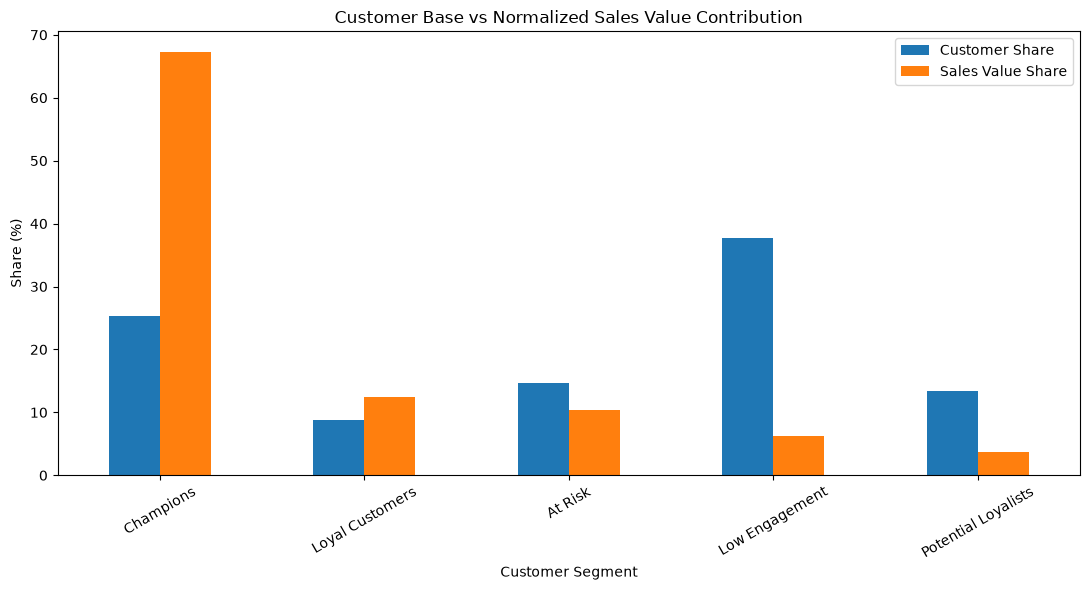

In [151]:
rfm_behavior_summary.plot(
    x="segment",
    y=["customer_share_pct", "sales_value_share_pct"],
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Customer Segment")
plt.ylabel("Share (%)")
plt.title("Customer Base vs Normalized Sales Value Contribution")
plt.xticks(rotation=30)
plt.legend(
    ["Customer Share", "Sales Value Share"]
)

plt.tight_layout()
plt.show()

In [152]:
customer_summary["purchase_frequency_group"] = pd.cut(
    customer_summary["transaction_count"],
    bins=[0, 1, 4, 12, 30, float("inf")],
    labels=[
        "One-time",
        "Occasional",
        "Repeat",
        "Frequent",
        "Highly Frequent"
    ]
)

frequency_summary = (
    customer_summary
    .groupby("purchase_frequency_group", observed=True)
    .agg(
        customer_count=("customer_id", "count"),
        total_sales_value=("total_sales_value", "sum"),
        avg_transactions=("transaction_count", "mean"),
        avg_sales_value=("total_sales_value", "mean")
    )
    .reset_index()
)

frequency_summary["customer_share_pct"] = (
    frequency_summary["customer_count"]
    / frequency_summary["customer_count"].sum()
    * 100
)

frequency_summary["sales_value_share_pct"] = (
    frequency_summary["total_sales_value"]
    / frequency_summary["total_sales_value"].sum()
    * 100
)

frequency_summary.round(2)

,purchase_frequency_group,customer_count,total_sales_value,avg_transactions,avg_sales_value,customer_share_pct,sales_value_share_pct
0,One-time,131514,4995.80,1.00,0.04,9.65,0.56
1,Occasional,305209,25597.89,2.85,0.08,22.40,2.89
2,Repeat,342098,72955.84,7.87,0.21,25.11,8.25
3,Frequent,281167,149565.76,20.01,0.53,20.64,16.91
4,Highly Frequent,302293,631530.68,74.33,2.09,22.19,71.39


In [153]:
customer_summary["is_repeat_customer"] = (
    customer_summary["transaction_count"] >= 2
)

repeat_rate_by_segment = (
    customer_summary
    .groupby("segment")
    .agg(
        customer_count=("customer_id", "count"),
        repeat_customers=("is_repeat_customer", "sum")
    )
    .reset_index()
)

repeat_rate_by_segment["repeat_customer_rate_pct"] = (
    repeat_rate_by_segment["repeat_customers"]
    / repeat_rate_by_segment["customer_count"]
    * 100
)

repeat_rate_by_segment.sort_values(
    "repeat_customer_rate_pct",
    ascending=False
).round(2)

,segment,customer_count,repeat_customers,repeat_customer_rate_pct
0,At Risk,200221,200221,100.00
1,Champions,344583,344583,100.00
3,Loyal Customers,119387,119387,100.00
4,Potential Loyalists,183477,166903,90.97
2,Low Engagement,514613,399673,77.66


In [154]:
segment_value = (
    customer_summary
    .groupby("segment")
    .agg(
        customer_count=("customer_id", "count"),
        total_sales_value=("total_sales_value", "sum"),
        avg_customer_value=("total_sales_value", "mean"),
        median_customer_value=("total_sales_value", "median")
    )
    .reset_index()
)

segment_value = segment_value.sort_values(
    "avg_customer_value",
    ascending=False
).reset_index(drop=True)

segment_value.round({
    "total_sales_value": 2,
    "avg_customer_value": 4,
    "median_customer_value": 4
})

,segment,customer_count,total_sales_value,avg_customer_value,median_customer_value
0,Champions,344583,594446.29,1.7251,1.1234
1,Loyal Customers,119387,110500.68,0.9256,0.6465
2,At Risk,200221,92016.97,0.4596,0.3107
3,Potential Loyalists,183477,32551.33,0.1774,0.1525
4,Low Engagement,514613,55130.71,0.1071,0.0788


In [155]:
seasonal_months = monthly_summary_full[
    ["month", "transaction_count", "total_sales_value", "avg_transaction_value"]
].copy()

seasonal_months["month_name"] = (
    seasonal_months["month"]
    .dt.strftime("%b")
)

seasonal_months["month_num"] = (
    seasonal_months["month"]
    .dt.month
)

seasonal_months = seasonal_months.sort_values(
    "month"
).reset_index(drop=True)

seasonal_months.round({
    "total_sales_value": 2,
    "avg_transaction_value": 5
})

,month,transaction_count,total_sales_value,avg_transaction_value,month_name,month_num
0,2018-09,594776,17755.64,0.02985,Sep,9
1,2018-10,1397040,41584.82,0.02977,Oct,10
2,2018-11,1270619,39000.99,0.03069,Nov,11
3,2018-12,1148827,32532.51,0.02832,Dec,12
4,2019-01,1263471,33449.98,0.02647,Jan,1
5,2019-02,1152412,31428.22,0.02727,Feb,2
6,2019-03,1286750,37549.02,0.02918,Mar,3
7,2019-04,1476454,42824.99,0.02901,Apr,4
8,2019-05,1560319,43357.50,0.02779,May,5
9,2019-06,1906202,48648.42,0.02552,Jun,6


In [156]:
calendar_month_summary = (
    seasonal_months[
        ~seasonal_months["month"].isin([
            pd.Period("2018-09"),
            pd.Period("2020-09")
        ])
    ]
    .groupby("month_num")
    .agg(
        avg_transactions=("transaction_count", "mean"),
        avg_sales_value=("total_sales_value", "mean"),
        avg_transaction_value=("avg_transaction_value", "mean"),
        years_observed=("month", "count")
    )
    .reset_index()
)

calendar_month_summary["month_name"] = pd.to_datetime(
    calendar_month_summary["month_num"],
    format="%m"
).dt.month_name()

calendar_month_summary = calendar_month_summary.sort_values(
    "month_num"
).reset_index(drop=True)

calendar_month_summary.round({
    "avg_transactions": 0,
    "avg_sales_value": 2,
    "avg_transaction_value": 5
})

,month_num,avg_transactions,avg_sales_value,avg_transaction_value,years_observed,month_name
0,1,1169912.0,31121.78,0.02661,2,January
1,2,1077136.0,30110.55,0.02801,2,February
2,3,1167251.0,33911.61,0.02904,2,March
3,4,1408668.0,40316.74,0.02860,2,April
4,5,1461067.0,40251.60,0.02753,2,May
5,6,1835354.0,45851.89,0.02496,2,June
6,7,1579498.0,36375.07,0.02315,2,July
7,8,1245361.0,31838.17,0.02557,2,August
8,9,1227178.0,40304.05,0.03284,1,September
9,10,1271906.0,39286.26,0.03101,2,October


In [157]:
overall_avg_transactions = (
    calendar_month_summary["avg_transactions"].mean()
)

calendar_month_summary["transaction_seasonality_index"] = (
    calendar_month_summary["avg_transactions"]
    / overall_avg_transactions
)

calendar_month_summary[
    [
        "month_name",
        "avg_transactions",
        "transaction_seasonality_index"
    ]
].round(2)

,month_name,avg_transactions,transaction_seasonality_index
0,January,1169912.5,0.89
1,February,1077135.5,0.82
2,March,1167251.0,0.89
3,April,1408668.0,1.07
4,May,1461067.0,1.11
5,June,1835354.5,1.39
6,July,1579498.0,1.20
7,August,1245361.0,0.95
8,September,1227178.0,0.93
9,October,1271906.0,0.97


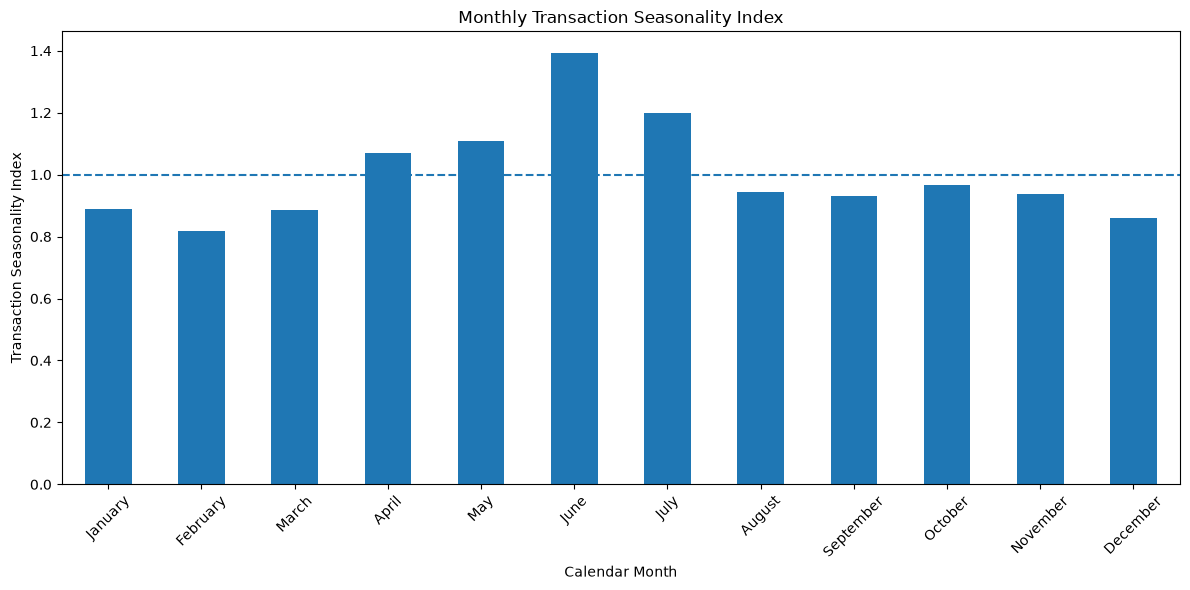

In [158]:
calendar_month_summary.plot(
    x="month_name",
    y="transaction_seasonality_index",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel("Calendar Month")
plt.ylabel("Transaction Seasonality Index")
plt.title("Monthly Transaction Seasonality Index")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [159]:
import os

raw_files = os.listdir("../data/raw")

for file in raw_files:
    print(file)

articles.csv
customers.csv
transactions_train.csv


In [160]:
calendar_month_summary.to_csv(
    "../data/processed/monthly_seasonality_summary.csv",
    index=False
)

seasonal_months.to_csv(
    "../data/processed/monthly_transaction_summary.csv",
    index=False
)

print("Seasonality analysis files saved successfully.")

Seasonality analysis files saved successfully.


In [161]:
channel_parts = []

for chunk in pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["sales_channel_id", "price"],
    chunksize=500_000
):
    summary = (
        chunk
        .groupby("sales_channel_id")
        .agg(
            transaction_count=("price", "count"),
            total_sales_value=("price", "sum")
        )
        .reset_index()
    )

    channel_parts.append(summary)

channel_summary = (
    pd.concat(channel_parts)
    .groupby("sales_channel_id")
    .agg(
        transaction_count=("transaction_count", "sum"),
        total_sales_value=("total_sales_value", "sum")
    )
    .reset_index()
)

channel_summary["transaction_share_pct"] = (
    channel_summary["transaction_count"]
    / channel_summary["transaction_count"].sum()
    * 100
)

channel_summary["sales_value_share_pct"] = (
    channel_summary["total_sales_value"]
    / channel_summary["total_sales_value"].sum()
    * 100
)

channel_summary["avg_transaction_value"] = (
    channel_summary["total_sales_value"]
    / channel_summary["transaction_count"]
)

channel_summary.round({
    "total_sales_value": 2,
    "transaction_share_pct": 2,
    "sales_value_share_pct": 2,
    "avg_transaction_value": 5
})

,sales_channel_id,transaction_count,total_sales_value,transaction_share_pct,sales_value_share_pct,avg_transaction_value
0,1,9408462,215682.83,29.6,24.38,0.02292
1,2,22379862,668963.15,70.4,75.62,0.02989


In [162]:
channel_summary["value_mix_gap_pp"] = (
    channel_summary["sales_value_share_pct"]
    - channel_summary["transaction_share_pct"]
)

channel_summary[
    [
        "sales_channel_id",
        "transaction_share_pct",
        "sales_value_share_pct",
        "value_mix_gap_pp",
        "avg_transaction_value"
    ]
].round(2)

,sales_channel_id,transaction_share_pct,sales_value_share_pct,value_mix_gap_pp,avg_transaction_value
0,1,29.6,24.38,-5.22,0.02
1,2,70.4,75.62,5.22,0.03


In [163]:
channel_summary.to_csv(
    "../data/processed/channel_summary.csv",
    index=False
)

rfm_behavior_summary.to_csv(
    "../data/processed/rfm_behavior_summary.csv",
    index=False
)

segment_value.to_csv(
    "../data/processed/segment_value_summary.csv",
    index=False
)

frequency_summary.to_csv(
    "../data/processed/purchase_frequency_summary.csv",
    index=False
)

print("Customer and channel analysis files saved successfully.")

Customer and channel analysis files saved successfully.


In [164]:
processed_files = os.listdir("../data/processed")

for file in sorted(processed_files):
    print(file)

assortment_breadth_summary.csv
category_price_band_summary.csv
category_price_summary.csv
channel_summary.csv
customer_rfm_segments.csv
dominant_category_price_band.csv
monthly_sales_summary.csv
monthly_seasonality_summary.csv
monthly_transaction_summary.csv
portfolio_segment_summary.csv
price_band_summary.csv
product_demand.csv
product_name_demand.csv
product_portfolio_matrix.csv
product_variant_demand.csv
purchase_frequency_summary.csv
rfm_behavior_summary.csv
rfm_segment_summary.csv
segment_value_summary.csv


In [165]:
powerbi_files = [
    "monthly_transaction_summary.csv",
    "channel_summary.csv",
    "rfm_segment_summary.csv",
    "category_price_summary.csv",
    "price_band_summary.csv",
    "category_price_band_summary.csv",
    "dominant_category_price_band.csv",
    "customer_rfm_segments.csv",
    "rfm_behavior_summary.csv",
    "segment_value_summary.csv",
    "purchase_frequency_summary.csv",
    "product_name_demand.csv",
    "product_portfolio_matrix.csv",
    "portfolio_segment_summary.csv",
    "product_variant_demand.csv",
    "assortment_breadth_summary.csv"
]

powerbi_folder = "../powerbi/data"

os.makedirs(powerbi_folder, exist_ok=True)

for file in powerbi_files:
    source = f"../data/processed/{file}"
    destination = f"{powerbi_folder}/{file}"

    import shutil
    shutil.copy2(source, destination)

print(f"Copied {len(powerbi_files)} files to:")
print(os.path.abspath(powerbi_folder))

Copied 16 files to:
c:\Users\bhumi\OneDrive\Documents\Luxury_Lifestyle_Category_Analytics\powerbi\data


In [1]:
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/13.7 MB ? eta -:--:--
   --- ------------------------------------ 1.0/13.7 MB 5.5 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/13.7 MB 4.6 MB/s eta 0:00:03
   ------- -------------------------------- 2.6/13.7 MB 4.3 MB/s eta 0:00:03
   --------- ------------------------------ 3.4/13.7 MB 4.2 MB/s eta 0:00:03
   ------------ --------------------------- 4.2/13.7 MB 4.1 MB/s eta 0:00:03
   --------------- ------------------------ 5.2/13.7 MB 4.1 MB/s eta 0:00:03
   ----------------- ---------------------- 6.0/13.7 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 6.8/13.7 MB 4.0 MB/s eta 0:00:02
   --------------------- ------------------ 7.3/13.7 MB 3.8 MB/s eta 0:00:02
   ------------------------ --------------- 8.4/13.7 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 9.2/13.7 MB 4.0 MB/s eta 0:00:02
   --


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [2]:
import duckdb

print("DuckDB version:", duckdb.__version__)

ModuleNotFoundError: No module named 'duckdb'

In [3]:
import sys
!{sys.executable} -m pip install duckdb

   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.2 MB ? eta -:--:--
   --- ------------------------------------ 1.3/13.2 MB 5.6 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/13.2 MB 4.7 MB/s eta 0:00:03
   --------- ------------------------------ 3.1/13.2 MB 4.3 MB/s eta 0:00:03
   ----------- ---------------------------- 3.9/13.2 MB 4.2 MB/s eta 0:00:03
   -------------- ------------------------- 4.7/13.2 MB 4.2 MB/s eta 0:00:03
   ---------------- ----------------------- 5.5/13.2 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 6.3/13.2 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 7.1/13.2 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 8.1/13.2 MB 4.0 MB/s eta 0:00:02
   --------------------------- ------------ 8.9/13.2 MB 4.0 MB/s eta 0:00:02
   ----------------------------- ---------- 9.7/13.2 MB 4.0 MB/s eta 0:00:01
   ----------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import duckdb

print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.6


In [5]:
import duckdb
import os

con = duckdb.connect()

print("Current folder:", os.getcwd())
print("DuckDB connection: OK")

Current folder: c:\Users\bhumi\OneDrive\Documents\Luxury_Lifestyle_Category_Analytics\notebook
DuckDB connection: OK


In [6]:
articles_sql_test = con.execute("""
    SELECT
        product_group_name,
        COUNT(*) AS article_count
    FROM read_csv_auto('../data/raw/articles.csv')
    GROUP BY product_group_name
    ORDER BY article_count DESC
    LIMIT 10
""").df()

articles_sql_test

,product_group_name,article_count
0,Garment Upper body,42741
1,Garment Lower body,19812
2,Garment Full body,13292
3,Accessories,11158
4,Underwear,5490
5,Shoes,5283
6,Swimwear,3127
7,Socks & Tights,2442
8,Nightwear,1899
9,Unknown,121


In [7]:
category_sql = con.execute("""
    SELECT
        a.product_group_name,
        COUNT(*) AS transaction_count,
        SUM(t.price) AS total_sales_value,
        AVG(t.price) AS avg_observed_price
    FROM read_csv_auto('../data/raw/transactions_train.csv') t
    LEFT JOIN read_csv_auto('../data/raw/articles.csv') a
        ON t.article_id = a.article_id
    GROUP BY a.product_group_name
    ORDER BY transaction_count DESC
""").df()

category_sql

,product_group_name,transaction_count,total_sales_value,avg_observed_price
0,Garment Upper body,12552755,338981.789204,0.027005
1,Garment Lower body,7046054,231774.620033,0.032894
2,Garment Full body,3552470,128478.941678,0.036166
3,Swimwear,2579222,57628.166509,0.022343
4,Underwear,2565858,54395.857458,0.021200
5,Accessories,1599593,24893.822424,0.015563
6,Shoes,745521,28888.356373,0.038749
7,Socks & Tights,685712,7811.136525,0.011391
8,Nightwear,348180,8852.815390,0.025426
9,Unknown,97040,2598.734051,0.026780


In [8]:
category_sql = con.execute("""
    WITH category_summary AS (
        SELECT
            a.product_group_name,
            COUNT(*) AS transaction_count,
            SUM(t.price) AS total_sales_value,
            AVG(t.price) AS avg_observed_price
        FROM read_csv_auto('../data/raw/transactions_train.csv') t
        LEFT JOIN read_csv_auto('../data/raw/articles.csv') a
            ON t.article_id = a.article_id
        GROUP BY a.product_group_name
    )

    SELECT
        product_group_name,
        transaction_count,
        ROUND(
            transaction_count * 100.0
            / SUM(transaction_count) OVER (),
            2
        ) AS transaction_share_pct,
        ROUND(total_sales_value, 2) AS total_sales_value,
        ROUND(
            total_sales_value * 100.0
            / SUM(total_sales_value) OVER (),
            2
        ) AS sales_value_share_pct,
        ROUND(avg_observed_price, 5) AS avg_observed_price
    FROM category_summary
    ORDER BY transaction_count DESC
""").df()

category_sql

,product_group_name,transaction_count,transaction_share_pct,total_sales_value,sales_value_share_pct,avg_observed_price
0,Garment Upper body,12552755,39.49,338981.79,38.32,0.02700
1,Garment Lower body,7046054,22.17,231774.62,26.20,0.03289
2,Garment Full body,3552470,11.18,128478.94,14.52,0.03617
3,Swimwear,2579222,8.11,57628.17,6.51,0.02234
4,Underwear,2565858,8.07,54395.86,6.15,0.02120
5,Accessories,1599593,5.03,24893.82,2.81,0.01556
6,Shoes,745521,2.35,28888.36,3.27,0.03875
7,Socks & Tights,685712,2.16,7811.14,0.88,0.01139
8,Nightwear,348180,1.10,8852.82,1.00,0.02543
9,Unknown,97040,0.31,2598.73,0.29,0.02678


In [9]:
category_sql.to_csv(
    "../data/processed/sql_category_analysis.csv",
    index=False
)

print("Saved: sql_category_analysis.csv")

Saved: sql_category_analysis.csv


In [10]:
customer_frequency_sql = con.execute("""
    SELECT
        customer_id,
        COUNT(*) AS transaction_count,
        SUM(price) AS total_sales_value
    FROM read_csv_auto('../data/raw/transactions_train.csv')
    GROUP BY customer_id
    ORDER BY transaction_count DESC
""").df()

customer_frequency_sql.head(10)

,customer_id,transaction_count,total_sales_value
0,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1895,57.676407
1,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,1441,47.662000
2,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,1364,30.126814
3,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,1361,50.921186
4,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,1237,41.327051
5,55d15396193dfd45836af3a6269a079efea339e875eff4...,1208,38.234102
6,c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27c...,1170,34.510153
7,8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d...,1169,39.759712
8,03d0011487606c37c1b1ed147fc72f285a50c05f00b971...,1157,49.967169
9,6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2...,1143,47.247797


In [11]:
customer_frequency_groups = con.execute("""
    WITH customer_summary AS (
        SELECT
            customer_id,
            COUNT(*) AS transaction_count,
            SUM(price) AS total_sales_value
        FROM read_csv_auto('../data/raw/transactions_train.csv')
        GROUP BY customer_id
    )

    SELECT
        customer_id,
        transaction_count,
        total_sales_value,
        CASE
            WHEN transaction_count = 1 THEN 'One-time'
            WHEN transaction_count BETWEEN 2 AND 4 THEN 'Occasional'
            WHEN transaction_count BETWEEN 5 AND 12 THEN 'Repeat'
            WHEN transaction_count BETWEEN 13 AND 30 THEN 'Frequent'
            ELSE 'Highly Frequent'
        END AS purchase_frequency_group
    FROM customer_summary
""").df()

customer_frequency_groups.head(10)

,customer_id,transaction_count,total_sales_value,purchase_frequency_group
0,3df88a281b5bfe0b9947950256f6007959841d8af68e8a...,84,2.165119,Highly Frequent
1,3e903512e9a04ebbdab0500a58bf2684e70ae209d968e3...,115,2.874441,Highly Frequent
2,3fece6d809b46c431b402337ddc5b3e05774e8e9168a13...,79,2.443576,Highly Frequent
3,40706deac49b839ea56b1f6b4eb85bc4f87949582b2af0...,2,0.038949,Occasional
4,41c48fc87db9ec1d9bc5792a63b680e0a1f04bec01e959...,27,0.932441,Frequent
5,41e3fd74c38af3f14e6f14d81c8d5d157c76a127aa6f34...,26,0.527356,Frequent
6,43858fe5d029abee22a1074765d86d7f142731f90b579b...,11,0.269746,Repeat
7,45cc3bd66856648687b3f811f7d989e353f8e2e6119404...,42,1.291678,Highly Frequent
8,4687e94246c7a4c0dead9b29dbbe81cb3c89bcfcdb23a8...,30,0.360932,Frequent
9,483e85cac5625bba2b8e7c742861933f72912ee1acb5c4...,32,0.822508,Highly Frequent


In [12]:
frequency_sql_summary = con.execute("""
    WITH customer_summary AS (
        SELECT
            customer_id,
            COUNT(*) AS transaction_count,
            SUM(price) AS total_sales_value
        FROM read_csv_auto('../data/raw/transactions_train.csv')
        GROUP BY customer_id
    ),

    frequency_groups AS (
        SELECT
            customer_id,
            transaction_count,
            total_sales_value,
            CASE
                WHEN transaction_count = 1 THEN 'One-time'
                WHEN transaction_count BETWEEN 2 AND 4 THEN 'Occasional'
                WHEN transaction_count BETWEEN 5 AND 12 THEN 'Repeat'
                WHEN transaction_count BETWEEN 13 AND 30 THEN 'Frequent'
                ELSE 'Highly Frequent'
            END AS purchase_frequency_group
        FROM customer_summary
    )

    SELECT
        purchase_frequency_group,
        COUNT(*) AS customer_count,
        SUM(transaction_count) AS total_transactions,
        ROUND(SUM(total_sales_value), 2) AS total_sales_value,
        ROUND(AVG(transaction_count), 2) AS avg_transactions,
        ROUND(AVG(total_sales_value), 4) AS avg_customer_value
    FROM frequency_groups
    GROUP BY purchase_frequency_group
    ORDER BY
        CASE purchase_frequency_group
            WHEN 'One-time' THEN 1
            WHEN 'Occasional' THEN 2
            WHEN 'Repeat' THEN 3
            WHEN 'Frequent' THEN 4
            WHEN 'Highly Frequent' THEN 5
        END
""").df()

frequency_sql_summary

,purchase_frequency_group,customer_count,total_transactions,total_sales_value,avg_transactions,avg_customer_value
0,One-time,131514,131514.0,4995.80,1.00,0.0380
1,Occasional,305209,870268.0,25597.89,2.85,0.0839
2,Repeat,342098,2690956.0,72955.84,7.87,0.2133
3,Frequent,281167,5625375.0,149565.76,20.01,0.5319
4,Highly Frequent,302293,22470211.0,631530.68,74.33,2.0891


In [13]:
frequency_sql_summary.to_csv(
    "../data/processed/sql_customer_frequency_analysis.csv",
    index=False
)

print("Saved: sql_customer_frequency_analysis.csv")

Saved: sql_customer_frequency_analysis.csv


In [14]:
price_band_sql = con.execute("""
    WITH price_data AS (
        SELECT
            price,
            NTILE(5) OVER (ORDER BY price) AS price_band_num
        FROM read_csv_auto('../data/raw/transactions_train.csv')
    ),

    price_bands AS (
        SELECT
            price,
            CASE
                WHEN price_band_num = 1 THEN 'Very Low'
                WHEN price_band_num = 2 THEN 'Low'
                WHEN price_band_num = 3 THEN 'Medium'
                WHEN price_band_num = 4 THEN 'High'
                WHEN price_band_num = 5 THEN 'Very High'
            END AS price_band
        FROM price_data
    ),

    band_summary AS (
        SELECT
            price_band,
            COUNT(*) AS transaction_count,
            SUM(price) AS total_sales_value,
            AVG(price) AS avg_observed_price
        FROM price_bands
        GROUP BY price_band
    )

    SELECT
        price_band,
        transaction_count,
        ROUND(
            transaction_count * 100.0
            / SUM(transaction_count) OVER (),
            2
        ) AS transaction_share_pct,
        ROUND(total_sales_value, 2) AS total_sales_value,
        ROUND(
            total_sales_value * 100.0
            / SUM(total_sales_value) OVER (),
            2
        ) AS sales_value_share_pct,
        ROUND(avg_observed_price, 5) AS avg_observed_price
    FROM band_summary
    ORDER BY
        CASE price_band
            WHEN 'Very Low' THEN 1
            WHEN 'Low' THEN 2
            WHEN 'Medium' THEN 3
            WHEN 'High' THEN 4
            WHEN 'Very High' THEN 5
        END
""").df()

price_band_sql

,price_band,transaction_count,transaction_share_pct,total_sales_value,sales_value_share_pct,avg_observed_price
0,Very Low,6357665,20.0,60582.80,6.85,0.00953
1,Low,6357665,20.0,106071.70,11.99,0.01668
2,Medium,6357665,20.0,153485.66,17.35,0.02414
3,High,6357665,20.0,206071.39,23.29,0.03241
4,Very High,6357664,20.0,358434.42,40.52,0.05638


In [15]:
price_band_sql.to_csv(
    "../data/processed/sql_price_band_analysis.csv",
    index=False
)

print("Saved: sql_price_band_analysis.csv")

Saved: sql_price_band_analysis.csv


In [16]:
product_family_sql = con.execute("""
    SELECT
        a.prod_name,
        COUNT(*) AS transaction_count,
        SUM(t.price) AS total_sales_value,
        COUNT(DISTINCT t.article_id) AS article_variant_count
    FROM read_csv_auto('../data/raw/transactions_train.csv') t
    LEFT JOIN read_csv_auto('../data/raw/articles.csv') a
        ON t.article_id = a.article_id
    GROUP BY a.prod_name
    ORDER BY transaction_count DESC
""").df()

product_family_sql.head(20)

,prod_name,transaction_count,total_sales_value,article_variant_count
0,Jade HW Skinny Denim TRS,168052,5398.928237,19
1,Luna skinny RW,143216,4178.059525,34
2,Timeless Midrise Brief,122143,1906.257949,30
3,Tilly (1),105670,852.298458,29
4,Cat Tee.,81304,656.533898,28
5,Simple as That Triangle Top,74827,1794.061712,17
6,Shake it in Balconette,74574,1637.161068,31
7,Tilda tank,68891,394.500186,20
8,Despacito,67607,1534.471051,48
9,Simple as that Cheeky Tanga,64603,1016.010898,14


In [17]:
product_family_sql.to_csv(
    "../data/processed/sql_product_portfolio_analysis.csv",
    index=False
)

print("Saved: sql_product_portfolio_analysis.csv")

Saved: sql_product_portfolio_analysis.csv


In [18]:
seasonality_sql = con.execute("""
    SELECT
        DATE_TRUNC('month', CAST(t_dat AS DATE)) AS month,
        COUNT(*) AS transaction_count,
        SUM(price) AS total_sales_value,
        AVG(price) AS avg_observed_price
    FROM read_csv_auto('../data/raw/transactions_train.csv')
    GROUP BY 1
    ORDER BY 1
""").df()

seasonality_sql.head(10)

,month,transaction_count,total_sales_value,avg_observed_price
0,2018-09-01,594776,17755.639593,0.029853
1,2018-10-01,1397040,41584.816610,0.029766
2,2018-11-01,1270619,39000.988390,0.030694
3,2018-12-01,1148827,32532.514712,0.028318
4,2019-01-01,1263471,33449.981475,0.026475
5,2019-02-01,1152412,31428.221814,0.027272
6,2019-03-01,1286750,37549.020170,0.029181
7,2019-04-01,1476454,42824.987305,0.029005
8,2019-05-01,1560319,43357.502322,0.027788
9,2019-06-01,1906202,48648.417864,0.025521


In [19]:
seasonality_index_sql = con.execute("""
    WITH monthly AS (
        SELECT
            DATE_TRUNC('month', CAST(t_dat AS DATE)) AS month,
            COUNT(*) AS transaction_count
        FROM read_csv_auto('../data/raw/transactions_train.csv')
        GROUP BY 1
    ),

    complete_months AS (
        SELECT *
        FROM monthly
        WHERE month NOT IN (
            DATE '2018-09-01',
            DATE '2020-09-01'
        )
    ),

    calendar_months AS (
        SELECT
            EXTRACT(MONTH FROM month) AS month_num,
            AVG(transaction_count) AS avg_transactions,
            COUNT(*) AS years_observed
        FROM complete_months
        GROUP BY 1
    )

    SELECT
        month_num,
        ROUND(avg_transactions, 0) AS avg_transactions,
        years_observed,
        ROUND(
            avg_transactions /
            AVG(avg_transactions) OVER (),
            2
        ) AS transaction_seasonality_index
    FROM calendar_months
    ORDER BY month_num
""").df()

seasonality_index_sql

,month_num,avg_transactions,years_observed,transaction_seasonality_index
0,1,1169913.0,2,0.89
1,2,1077136.0,2,0.82
2,3,1167251.0,2,0.89
3,4,1408668.0,2,1.07
4,5,1461067.0,2,1.11
5,6,1835355.0,2,1.39
6,7,1579498.0,2,1.20
7,8,1245361.0,2,0.95
8,9,1227178.0,1,0.93
9,10,1271906.0,2,0.97


In [20]:
seasonality_index_sql.to_csv(
    "../data/processed/sql_seasonality_analysis.csv",
    index=False
)

print("Saved: sql_seasonality_analysis.csv")

Saved: sql_seasonality_analysis.csv
